# Forecasting from Sparse ERA5 Observations

Reconstruct fields from sparse observations, then compare direct and push-forward forecasts.

Run the reconstruction section first. The forecasting sections use its model and data.

## 0. Dependencies

### 0.1 Install mapping dependency

In [1]:
%pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 119.5 MB/s eta 0:00:0000:010:01


## 1. Imports

### 1.1 Install Zarr support

In [2]:
# À exécuter dans une cellule Jupyter AVANT open_dataset()
import sys
!{sys.executable} -m pip install -q "zarr>=2.18" "fsspec>=2024.0.0" "gcsfs>=2024.0.0"

import zarr
import xarray as xr

print("zarr OK:", zarr.__version__)
print("xarray OK:", xr.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 8.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.4 MB/s eta 0:00:00:00:0100:01
zarr OK: 3.2.1
xarray OK: 2025.12.0


### 1.2 Import libraries

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.spatial import cKDTree
import xarray as xr
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity
except Exception:
    structural_similarity = None


## 2. Configuration

### 2.1 Set experiment parameters

In [4]:
# ── Données ────────────────────────────────────────────────────────────────
ERA5_PATH    = "gs://weatherbench2/datasets/era5/1959-2022-6h-64x32_equiangular_conservative.zarr"
TIME_SLICE   = slice(0, 2000)
LEVEL_TARGET = 850

VAR_CANDIDATES = {
    "u":   ["10m_u_component_of_wind", "u10"],
    "v":   ["10m_v_component_of_wind", "v10"],
    "z":   ["geopotential", "z"],
    "q":   ["specific_humidity", "q"],
    "t2m": ["2m_temperature", "t2m"],
}
MULTIVAR_KEYS = ["z", "q", "t2m", "u", "v"]

# ── Capteurs / masque ──────────────────────────────────────────────────────
KEEP_RATIO   = 0.1
A_KEEP_RATIO = 0.05   # Section A explicite à 5% pour reproductibilité des notes
SEED_TRAIN = 10
SEED_VAL   = 20
SEED_TEST  = 30

# ── Split ──────────────────────────────────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

# ── Entraînement ──────────────────────────────────────────────────────────
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_EVAL  = 32
LR               = 1e-3
WEIGHT_DECAY     = 1e-4
MAX_EPOCHS       = 30
PATIENCE         = 5

# ── Architecture ──────────────────────────────────────────────────────────
UNET_BASE = 64

# ── Architecture GNN ──────────────────────────────────────────────────────
GNN_HIDDEN_DIM = 128
GNN_NUM_LAYERS = 4
GNN_KNN_K      = 8

# ── Loss multivariée ──────────────────────────────────────────────────────
# Référence potentielle de pondération par variable.
# `FIXED_LOSS_WEIGHTS = None` => poids unitaires dans les sections multivariées à poids fixes.
# Sinon fournir une liste explicite alignée sur MULTIVAR_KEYS.
MULTIVAR_WEIGHTS   = [1, 1, 1, 1, 1]  # (z, q, t2m, u, v)
FIXED_LOSS_WEIGHTS = None
WEIGHT_UNKNOWN     = 0.8
WEIGHT_ALL         = 0.2
LAMBDA_GRAD        = 2.5             # poids gradient loss (augmenter → moins de lissage)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

# Reproductibilité complète
GLOBAL_SEED = 42
torch.manual_seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)
print(f"Seeds fixées : {GLOBAL_SEED}")


Device : cuda
Seeds fixées : 42


## 3. Load ERA5 data

### 3.1 Load ERA5

In [ ]:
def open_dataset():
    """Ouvre ERA5 depuis Google Cloud Storage (accès anonyme)."""
    ds = xr.open_zarr(ERA5_PATH, storage_options={"token": "anon"})
    return ds


def to_THW(da, level_target=LEVEL_TARGET, time_slice=TIME_SLICE):
    """Extrait un DataArray ERA5 en array float32 (T, H, W)."""
    if "level" in da.dims:
        da = da.sel(level=level_target, method="nearest")
    da = da.isel(time=time_slice)
    lat_dim = next((d for d in da.dims if d in ("lat", "latitude")), None)
    lon_dim = next((d for d in da.dims if d in ("lon", "longitude")), None)
    da = da.transpose("time", lat_dim, lon_dim)
    return da.astype("float32").values


def get_lat_weights_2d(ds):
    """Poids latitude cos(lat), normalisés à moyenne 1, shape (H,W)."""
    lat_name = "lat" if "lat" in ds.coords else ("latitude" if "latitude" in ds.coords else None)
    lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
    if lat_name is None or lon_name is None:
        raise RuntimeError("Coordonnées lat/lon introuvables pour calculer les poids latitude.")

    lat = np.asarray(ds[lat_name].values, dtype=np.float32)
    lon = np.asarray(ds[lon_name].values, dtype=np.float32)
    w_lat = np.cos(np.deg2rad(lat)).astype(np.float32)
    w_lat = np.clip(w_lat, 1e-6, None)

    w2d = np.repeat(w_lat[:, None], len(lon), axis=1)
    w2d = w2d / (float(np.mean(w2d)) + 1e-12)
    return w2d.astype(np.float32)


def build_climatology_univariate(T_train: np.ndarray) -> np.ndarray:
    """Climatologie 2D pour ACC: moyenne temporelle sur split train."""
    if T_train.ndim != 3:
        raise ValueError(f"T_train doit être (T,H,W), reçu {T_train.shape}")
    return T_train.mean(axis=0).astype(np.float32)


def build_climatology_maps(fields: dict, keys: list, idx_train: np.ndarray) -> dict:
    """Climatologie 2D par variable sur split train."""
    maps = {}
    for k in keys:
        maps[k] = fields[k][idx_train].mean(axis=0).astype(np.float32)
    return maps


def load_fields(ds, keys):
    """Charge plusieurs variables et retourne un dict {clé: array (T,H,W)}."""
    fields = {}
    for k in keys:
        candidates = VAR_CANDIDATES[k]
        vname = next((c for c in candidates if c in ds.data_vars), None)
        if vname is None:
            print(f"[loader] Variable '{k}' introuvable, ignorée.")
            continue
        fields[k] = to_THW(ds[vname])
        print(f"[loader] {k} ({vname}): {fields[k].shape}")
    return fields


def compute_split_indices(n, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO):
    """Split temporel 70/15/15 → (idx_train, idx_val, idx_test)."""
    n_train = int(train_ratio * n)
    n_val   = int(val_ratio * n)
    return (np.arange(0, n_train),
            np.arange(n_train, n_train + n_val),
            np.arange(n_train + n_val, n))


def compute_stats(fields, idx_train):
    """Calcule moyenne et écart-type sur le split train uniquement."""
    means, stds = {}, {}
    for k, arr in fields.items():
        means[k] = float(arr[idx_train].mean())
        stds[k]  = float(arr[idx_train].std() + 1e-6)
        print(f"[loader] {k}: mu={means[k]:.4f}, sigma={stds[k]:.4f}")
    return means, stds


## 4. Sparse masks and Voronoi interpolation

### 4.1 Define masks and Voronoi interpolation

In [6]:
def make_sparse_mask(h, w, keep_ratio=KEEP_RATIO, rng=None):
    """Masque binaire (H,W) float32 avec keep_ratio*H*W pixels à 1."""
    rng = np.random.default_rng() if rng is None else rng
    n = h * w
    k = max(1, int(round(keep_ratio * n)))
    idx = rng.choice(n, size=k, replace=False)
    m = np.zeros(n, dtype=np.float32)
    m[idx] = 1.0
    return m.reshape(h, w)


def voronoi_fill_from_sparse(field, mask):
    """Interpolation plus proche voisin depuis les capteurs (mask==1)."""
    ys, xs = np.where(mask == 1)
    vals = field[ys, xs]
    pts  = np.stack([ys, xs], axis=1)
    gy, gx = np.meshgrid(np.arange(field.shape[0]), np.arange(field.shape[1]), indexing="ij")
    query = np.stack([gy.ravel(), gx.ravel()], axis=1)
    tree = cKDTree(pts)
    _, nn = tree.query(query, k=1)
    return vals[nn].reshape(field.shape).astype(np.float32)

## 5. PyTorch datasets

### 5.1 Define datasets

In [7]:
class SparseVoronoiDataset(Dataset):
    """
    Dataset univarié.
    Retourne : x (3,H,W), y (1,H,W), m (1,H,W)
    """
    def __init__(self, T, mu, sigma, keep_ratio=KEEP_RATIO, base_seed=0,
                 absolute_indices=None):
        self.T, self.mu, self.sigma = T, mu, sigma
        self.keep_ratio, self.base_seed = keep_ratio, base_seed
        if absolute_indices is None:
            self.absolute_indices = np.arange(len(T), dtype=int)
        else:
            self.absolute_indices = np.array(absolute_indices, dtype=int)
            if len(self.absolute_indices) != len(T):
                raise ValueError("absolute_indices doit avoir la même longueur que T")

    def __len__(self):
        return len(self.T)

    def __getitem__(self, i):
        field = self.T[i]
        t_abs = int(self.absolute_indices[i])
        rng   = np.random.default_rng(self.base_seed + t_abs)
        mask  = make_sparse_mask(field.shape[0], field.shape[1], self.keep_ratio, rng)
        vor   = voronoi_fill_from_sparse(field, mask)
        sparse = field * mask

        x = np.stack([(vor - self.mu) / self.sigma,
                       mask,
                       (sparse - self.mu) / self.sigma], axis=0)
        y = ((field - self.mu) / self.sigma)[None]
        m = mask[None]
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(m, dtype=torch.float32))


class MultiSparseVoronoiDataset(Dataset):
    """
    Dataset multivarié (K variables).
    Retourne : x (3*K,H,W), y (K,H,W), m (K,H,W)
    """
    def __init__(self, fields, keys, means, stds, indices,
                 keep_ratio=KEEP_RATIO, base_seed=0, different_masks=False):
        self.fields, self.keys   = fields, list(keys)
        self.means, self.stds    = means, stds
        self.indices             = np.array(indices, dtype=int)
        self.keep_ratio          = keep_ratio
        self.base_seed           = base_seed
        self.different_masks     = different_masks
        _, self.H, self.W = fields[self.keys[0]].shape

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t = int(self.indices[i])
        rng_main    = np.random.default_rng(self.base_seed + t)
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch, y_ch, m_ch = [], [], []
        for vi, k in enumerate(self.keys):
            field = self.fields[k][t]
            mu, sig = self.means[k], self.stds[k]
            if self.different_masks:
                rng_k = np.random.default_rng(self.base_seed + t * 1000 + vi)
                mask  = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask
            vor    = voronoi_fill_from_sparse(field, mask)
            sparse = field * mask
            x_ch += [(vor - mu) / sig, mask.astype(np.float32), (sparse - mu) / sig]
            y_ch.append(((field - mu) / sig).astype(np.float32))
            m_ch.append(mask.astype(np.float32))

        return (torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32),
                torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32),
                torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32))


## 6. StrongUNet architecture

### 6.1 Define StrongUNet

In [8]:
# models/trueunet.py — architecture StrongUNet (univarié et multivarié)
#
# Améliorations :
#   - Connexions résiduelles dans chaque ConvBlock (style ResNet)
#   - Skip connections denses (style U-Net++)
#   - CBAM (Channel + Spatial Attention) après chaque bloc résiduel
#   - BatchNorm + Dropout2d au bottleneck

import torch
import torch.nn as nn


# ── CBAM ──────────────────────────────────────────────────────────────────────

class ChannelAttention(nn.Module):
    """
    Recalibre l'importance de chaque canal (feature map).

    AvgPool + MaxPool → MLP partagé → sigmoid → poids par canal
    reduction : facteur de compression du MLP (défaut 16)
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid = max(1, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )

    def forward(self, x):                          # x : (B, C, H, W)
        avg = x.mean(dim=(2, 3))                   # (B, C)
        mx  = x.amax(dim=(2, 3))                   # (B, C)
        w   = torch.sigmoid(self.mlp(avg) + self.mlp(mx))  # (B, C)
        return x * w[:, :, None, None]


class SpatialAttention(nn.Module):
    """
    Recalibre l'importance de chaque position spatiale (détection de motifs globaux).

    [AvgPool(C), MaxPool(C)] → concat → Conv 7×7 → sigmoid → poids spatial
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)

    def forward(self, x):                          # x : (B, C, H, W)
        avg = x.mean(dim=1, keepdim=True)          # (B, 1, H, W)
        mx  = x.amax(dim=1, keepdim=True)          # (B, 1, H, W)
        w   = torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))  # (B, 1, H, W)
        return x * w


class CBAM(nn.Module):
    """
    Convolutional Block Attention Module (Woo et al., 2018).
    Channel Attention → Spatial Attention en séquence.
    """
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


# ── ConvBlock résiduel + CBAM ─────────────────────────────────────────────────

class ConvBlock(nn.Module):
    """
    Double conv → BN avec connexion résiduelle (ResNet) et CBAM.

    Structure :
        x → Conv→BN→ReLU→Conv→BN → + shortcut(x) → CBAM → ReLU → [Dropout2d]

    Le CBAM recalibre canaux et positions spatiales avant le ReLU final.
    """
    def __init__(self, c_in: int, c_out: int, dropout: float = 0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in,  c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
        )
        self.shortcut = (
            nn.Sequential(nn.Conv2d(c_in, c_out, 1, bias=False),
                          nn.BatchNorm2d(c_out))
            if c_in != c_out else nn.Identity()
        )
        self.cbam    = CBAM(c_out)
        self.relu    = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, x):
        out = self.cbam(self.conv(x) + self.shortcut(x))
        return self.dropout(self.relu(out))


# ── StrongUNet ────────────────────────────────────────────────────────────────

class StrongUNet(nn.Module):
    """
    U-Net à 3 niveaux avec :
      - Connexions résiduelles dans chaque ConvBlock (ResNet)
      - CBAM (Channel + Spatial Attention) après chaque bloc
      - Skip connections denses (U-Net++) :
            d3 ← up(b)  + e3
            d2 ← up(d3) + e2 + pool(e1)
            d1 ← up(d2) + e1 + up(e2)

    Paramètres
    ----------
    in_ch   : 3 (univarié) ou 3*K (multivarié)
    out_ch  : 1 (univarié) ou K   (multivarié)
    base    : canaux de base (×2 à chaque niveau, ×8 au goulot)
    dropout : Dropout2d au bottleneck

    Canaux (base=64) :
        e1 →  64  | pleine résolution  (32×64)
        e2 → 128  | /2                 (16×32)
        e3 → 256  | /4                 ( 8×16)
        b  → 512  | /8 — goulot        ( 4× 8)
    """

    def __init__(self, in_ch: int = 3, out_ch: int = 1,
                 base: int = 64, dropout: float = 0.3):
        super().__init__()

        # ── Encodeur ──────────────────────────────────────────────────────────
        self.e1 = ConvBlock(in_ch,    base)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlock(base,     base * 2)
        self.p2 = nn.MaxPool2d(2)
        self.e3 = ConvBlock(base * 2, base * 4)
        self.p3 = nn.MaxPool2d(2)

        # ── Goulot ────────────────────────────────────────────────────────────
        self.b  = ConvBlock(base * 4, base * 8, dropout=dropout)

        # ── Décodeur niveau 3 : cat(up(b), e3) → 512+256=768 → 256 ──────────
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.d3 = ConvBlock(base * 8, base * 4)

        # ── Décodeur niveau 2 : cat(up(d3), e2, pool(e1)) → 256+128+64=448 → 128
        self.u2           = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.pool_e1_to_2 = nn.MaxPool2d(2)
        self.d2           = ConvBlock(base * 4 + base, base * 2)

        # ── Décodeur niveau 1 : cat(up(d2), e1, up(e2)) → 128+64+128=320 → 64
        self.u1         = nn.ConvTranspose2d(base * 2, base,     2, stride=2)
        self.up_e2_to_1 = nn.ConvTranspose2d(base * 2, base * 2, 2, stride=2)
        self.d1         = ConvBlock(base + base + base * 2, base)

        # ── Sortie ────────────────────────────────────────────────────────────
        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        # Encodeur
        e1 = self.e1(x)
        e2 = self.e2(self.p1(e1))
        e3 = self.e3(self.p2(e2))
        b  = self.b(self.p3(e3))

        # Décodeur niveau 3
        d3 = self.d3(torch.cat([self.u3(b), e3], dim=1))

        # Décodeur niveau 2 : + e1 downsamplé
        e1_down = self.pool_e1_to_2(e1)
        d2 = self.d2(torch.cat([self.u2(d3), e2, e1_down], dim=1))

        # Décodeur niveau 1 : + e2 upsamplé
        e2_up = self.up_e2_to_1(e2)
        d1 = self.d1(torch.cat([self.u1(d2), e1, e2_up], dim=1))

        return self.out(d1)


# ── Baseline Fukami (sans skip connections) ─────────────────────────────────

class ConvBlockPlain(nn.Module):
    """Bloc conv simple (pas de résidu, pas de skip global)."""
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class FukamiBaseline(nn.Module):
    """
    Baseline encodeur-décodeur sans skip connections.
    Sert de référence "modèle de base" pour comparaison avec StrongUNet.
    """
    def __init__(self, in_ch: int, out_ch: int, base: int = 64, dropout: float = 0.2):
        super().__init__()
        self.e1 = ConvBlockPlain(in_ch, base)
        self.p1 = nn.MaxPool2d(2)
        self.e2 = ConvBlockPlain(base, base * 2)
        self.p2 = nn.MaxPool2d(2)
        self.b  = ConvBlockPlain(base * 2, base * 4)
        self.drop = nn.Dropout2d(dropout)

        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.d2 = ConvBlockPlain(base * 2, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.d1 = ConvBlockPlain(base, base)

        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        x = self.e1(x)
        x = self.e2(self.p1(x))
        x = self.b(self.p2(x))
        x = self.d2(self.u2(self.drop(x)))
        x = self.d1(self.u1(x))
        return self.out(x)


## 7. Loss functions

### 7.1 Define losses

In [9]:
def gradient_loss(pred, y):
    """
    Pénalise les différences de gradients spatiaux entre pred et GT.
    Force la reconstruction des contours et structures fines (fronts, etc.)
    pred, y : (B, C, H, W)
    """
    gx_pred = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    gx_gt   = y[:, :, :, 1:]   - y[:, :, :, :-1]
    gy_pred = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    gy_gt   = y[:, :, 1:, :]   - y[:, :, :-1, :]
    return ((gx_pred - gx_gt) ** 2).mean() + ((gy_pred - gy_gt) ** 2).mean()


def loss_fn(pred, y, m):
    """Loss univariée : priorité aux points non observés + gradient loss."""
    unknown   = 1.0 - m
    l_unknown = ((pred - y) ** 2 * unknown).sum() / (unknown.sum() + 1e-6)
    l_all     = ((pred - y) ** 2).mean()
    l_mse     = WEIGHT_UNKNOWN * l_unknown + WEIGHT_ALL * l_all
    return l_mse + LAMBDA_GRAD * gradient_loss(pred, y)


def loss_fn_mv(pred, y, m, weights, device=device):
    """Loss multivariée avec poids adaptatifs + gradient loss."""
    w    = torch.tensor(weights, dtype=torch.float32, device=device)
    err2 = (pred - y) ** 2 * w[None, :, None, None]
    unknown   = 1.0 - m
    l_unknown = (err2 * unknown).sum() / (unknown.sum() + 1e-6)
    l_all     = err2.mean()
    l_mse     = WEIGHT_UNKNOWN * l_unknown + WEIGHT_ALL * l_all
    return l_mse + LAMBDA_GRAD * gradient_loss(pred, y)


def compute_adaptive_weights(nrmse_dict, keys):
    """poids_k = NRMSE_k / mean(NRMSE) — somme des poids = K."""
    vals  = [nrmse_dict[k] for k in keys]
    total = sum(vals)
    K     = len(keys)
    return [v / total * K for v in vals]


## 8. Training loops

### 8.1 Define training loops

In [10]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn_callable,
                device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Boucle d'entraînement générique avec early stopping (univarié)."""
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_callable(model(x), y, m)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_callable(model(x), y, m).item())

        tr_mean, va_mean = float(np.mean(tr_losses)), float(np.mean(va_losses))
        print(f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f}", flush=True)

        if va_mean < best_val - 1e-5:
            best_val   = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


def train_model_adaptive(model, train_loader, val_loader, optimizer, keys,
                         device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """
    Boucle multivariée avec poids adaptatifs.

    Correctifs:
    - NRMSE de référence calculée en global epoch (SSE/N), pas moyenne de RMSE batch.
    - Early stopping sur val_nrmse_mean_ref (échelle fixe inter-epochs).
    """
    K = len(keys)
    weights = [1.0] * K
    best_ref, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        # ── Entraînement ───────────────────────────────────────────────────
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        # ── Validation: diagnostic adaptatif + NRMSE ref (SSE/N) ───────────
        model.eval()
        va_losses_adaptive = []
        sse_ref = {k: 0.0 for k in keys}
        n_ref = {k: 0.0 for k in keys}

        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                pred = model(x)
                va_losses_adaptive.append(loss_fn_mv(pred, y, m, weights, device).item())

                for i, k in enumerate(keys):
                    e2 = (pred[:, i] - y[:, i]) ** 2
                    sse_ref[k] += float(e2.sum().item())
                    n_ref[k] += float(e2.numel())

        nrmse_mean = {
            k: float(np.sqrt(sse_ref[k] / max(n_ref[k], 1.0)))
            for k in keys
        }
        val_nrmse_mean_ref = float(np.mean([nrmse_mean[k] for k in keys]))

        # Mise à jour des poids pour l'epoch suivante
        weights = compute_adaptive_weights(nrmse_mean, keys)

        tr_mean = float(np.mean(tr_losses))
        va_adapt_mean = float(np.mean(va_losses_adaptive))
        w_str = " | ".join(f"{k}={weights[i]:.3f}" for i, k in enumerate(keys))
        print(
            f"Epoch {epoch:02d} | train={tr_mean:.5f} | val_adapt={va_adapt_mean:.5f} | "
            f"val_nrmse_ref={val_nrmse_mean_ref:.5f} | poids [{w_str}]",
            flush=True,
        )

        # ── Early stopping sur métrique fixe ───────────────────────────────
        if val_nrmse_mean_ref < best_ref - 1e-5:
            best_ref = val_nrmse_mean_ref
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val_nrmse_ref : {best_ref:.5f}", flush=True)
    return model


def train_model_fixed_weights(model, train_loader, val_loader, optimizer, keys,
                              device, fixed_weights=None,
                              max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Boucle multivariée avec poids fixes (pas d'ajustement adaptatif)."""
    K = len(keys)
    if fixed_weights is None:
        weights = [1.0] * K
    else:
        if len(fixed_weights) != K:
            raise ValueError(f"fixed_weights doit avoir longueur {K}, reçu {len(fixed_weights)}")
        weights = [float(w) for w in fixed_weights]

    print(
        "[train_model_fixed_weights] Note: val_loss comparable intra-run uniquement; "
        "inter-run, comparer plutôt NRMSE/ACC/SSIM.",
        flush=True,
    )

    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_mv(model(x), y, m, weights, device).item())

        tr_mean = float(np.mean(tr_losses))
        va_mean = float(np.mean(va_losses))
        w_str = " | ".join(f"{k}={weights[i]:.2f}" for i, k in enumerate(keys))
        print(f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f} | poids fixes [{w_str}]", flush=True)

        if va_mean < best_val - 1e-5:
            best_val   = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


## 9. Evaluation metrics

### 9.1 Define evaluation metrics

In [11]:
# evaluate.py — RMSE/NRMSE + ACC climatologique (WeatherBench simplifié) + SSIM locale

import numpy as np
import torch

try:
    from skimage.metrics import structural_similarity
except Exception:
    structural_similarity = None


def _resolve_lat_weights(lat_weights_2d):
    if lat_weights_2d is not None:
        return np.asarray(lat_weights_2d, dtype=np.float32)
    for name in ["LAT_WEIGHTS_2D_A", "LAT_WEIGHTS_2D_B", "LAT_WEIGHTS_2D", "LAT_WEIGHTS_2D_F", "LAT_WEIGHTS_2D_D", "LAT_WEIGHTS_2D_E"]:
        if name in globals():
            return np.asarray(globals()[name], dtype=np.float32)
    raise RuntimeError("Poids latitude introuvables. Calculer get_lat_weights_2d(ds) avant l'évaluation.")


def _resolve_clim_uni(climatology_map):
    if climatology_map is not None:
        return np.asarray(climatology_map, dtype=np.float32)
    for name in ["CLIM_UNI_MAP_A", "CLIM_UNI_MAP"]:
        if name in globals():
            return np.asarray(globals()[name], dtype=np.float32)
    raise RuntimeError("Climatologie univariée introuvable. Construire CLIM_UNI_MAP_A sur le train.")


def _resolve_clim_mv(climatology_maps, keys):
    if climatology_maps is not None:
        return {k: np.asarray(climatology_maps[k], dtype=np.float32) for k in keys}
    for name in ["CLIM_MV_MAPS_B", "CLIM_MV_MAPS", "CLIM_MV_MAPS_D", "CLIM_MV_MAPS_E", "CLIM_MV_MAPS_F"]:
        if name in globals():
            src = globals()[name]
            if isinstance(src, dict) and all(k in src for k in keys):
                return {k: np.asarray(src[k], dtype=np.float32) for k in keys}
    raise RuntimeError("Climatologie multivariée introuvable. Construire build_climatology_maps(...) sur le train.")


def ssim_2d(pred: np.ndarray, gt: np.ndarray) -> float:
    """SSIM locale (fenêtre glissante), version skimage standard."""
    if structural_similarity is None:
        raise ImportError("skimage.metrics.structural_similarity indisponible. Installer scikit-image.")

    pred = np.asarray(pred, dtype=np.float32)
    gt = np.asarray(gt, dtype=np.float32)
    data_min = float(min(pred.min(), gt.min()))
    data_max = float(max(pred.max(), gt.max()))
    data_range = max(data_max - data_min, 1e-6)

    h, w = pred.shape
    max_win = min(h, w)
    if max_win % 2 == 0:
        max_win -= 1
    win = min(11, max_win)
    if win < 3:
        return float("nan")

    return float(
        structural_similarity(
            gt,
            pred,
            data_range=data_range,
            gaussian_weights=True,
            sigma=1.5,
            use_sample_covariance=False,
            win_size=win,
        )
    )


def acc_2d(pred: np.ndarray, gt: np.ndarray, climatology_map: np.ndarray, lat_weights_2d: np.ndarray) -> float:
    """ACC WeatherBench simplifié: anomalies vs climatologie + pondération cos(lat)."""
    pred = np.asarray(pred, dtype=np.float64)
    gt = np.asarray(gt, dtype=np.float64)
    clim = np.asarray(climatology_map, dtype=np.float64)
    w = np.asarray(lat_weights_2d, dtype=np.float64)

    pa = pred - clim
    ga = gt - clim

    num = np.sum(w * pa * ga)
    den = np.sqrt(np.sum(w * pa * pa) * np.sum(w * ga * ga))
    if den < 1e-12:
        return float("nan")
    return float(num / den)


def evaluate_univariate(model, test_loader, mu: float, sigma: float,
                        device, climatology_map=None, lat_weights_2d=None) -> dict:
    """Évaluation univariée avec RMSE/NRMSE + ACC climatologique + SSIM locale."""
    model.eval()
    clim = _resolve_clim_uni(climatology_map)
    w_lat = _resolve_lat_weights(lat_weights_2d)

    sse_all, n_all = 0.0, 0.0
    sse_unknown, n_unknown = 0.0, 0.0
    acc_sum, acc_n = 0.0, 0
    ssim_sum, ssim_n = 0.0, 0

    with torch.no_grad():
        for x, y, m in test_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            pred = model(x)

            pred_k = pred * sigma + mu
            y_k = y * sigma + mu

            e2 = (pred_k - y_k) ** 2
            sse_all += float(e2.sum().item())
            n_all += float(e2.numel())

            unknown = 1.0 - m
            sse_unknown += float((e2 * unknown).sum().item())
            n_unknown += float(unknown.sum().item())

            pred_np = pred_k.squeeze(1).cpu().numpy()  # (B,H,W)
            y_np = y_k.squeeze(1).cpu().numpy()
            for b in range(pred_np.shape[0]):
                a = acc_2d(pred_np[b], y_np[b], clim, w_lat)
                if np.isfinite(a):
                    acc_sum += float(a)
                    acc_n += 1

                s = ssim_2d(pred_np[b], y_np[b])
                if np.isfinite(s):
                    ssim_sum += float(s)
                    ssim_n += 1

    rmse_g = float(np.sqrt(sse_all / max(n_all, 1.0)))
    rmse_u = float(np.sqrt(sse_unknown / max(n_unknown, 1.0)))

    return {
        "rmse_global": rmse_g,
        "rmse_unknown": rmse_u,
        "nrmse_global": rmse_g / sigma,
        "nrmse_unknown": rmse_u / sigma,
        "acc": float(acc_sum / max(acc_n, 1)),
        "ssim": float(ssim_sum / max(ssim_n, 1)),
    }


def evaluate_multivariate(model, test_loader, keys: list,
                          means: dict, stds: dict, device,
                          climatology_maps=None, lat_weights_2d=None) -> dict:
    """Évaluation multivariée avec ACC climatologique et SSIM locale."""
    model.eval()
    clim_maps = _resolve_clim_mv(climatology_maps, keys)
    w_lat = _resolve_lat_weights(lat_weights_2d)

    sse_all = {k: 0.0 for k in keys}
    n_all = {k: 0.0 for k in keys}
    sse_unknown = {k: 0.0 for k in keys}
    n_unknown = {k: 0.0 for k in keys}

    acc_sum = {k: 0.0 for k in keys}
    acc_n = {k: 0 for k in keys}
    ssim_sum = {k: 0.0 for k in keys}
    ssim_n = {k: 0 for k in keys}

    with torch.no_grad():
        for x, y, m in test_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            pred = model(x)

            for i, k in enumerate(keys):
                mu, sig = means[k], stds[k]
                pred_k = pred[:, i] * sig + mu
                y_k = y[:, i] * sig + mu

                e2 = (pred_k - y_k) ** 2
                sse_all[k] += float(e2.sum().item())
                n_all[k] += float(e2.numel())

                unknown = 1.0 - m[:, i]
                sse_unknown[k] += float((e2 * unknown).sum().item())
                n_unknown[k] += float(unknown.sum().item())

                pred_np = pred_k.cpu().numpy()
                y_np = y_k.cpu().numpy()
                clim_k = clim_maps[k]
                for b in range(pred_np.shape[0]):
                    a = acc_2d(pred_np[b], y_np[b], clim_k, w_lat)
                    if np.isfinite(a):
                        acc_sum[k] += float(a)
                        acc_n[k] += 1

                    s = ssim_2d(pred_np[b], y_np[b])
                    if np.isfinite(s):
                        ssim_sum[k] += float(s)
                        ssim_n[k] += 1

    results = {}
    for k in keys:
        rmse_g = float(np.sqrt(sse_all[k] / max(n_all[k], 1.0)))
        rmse_u = float(np.sqrt(sse_unknown[k] / max(n_unknown[k], 1.0)))
        results[k] = {
            "rmse_global": rmse_g,
            "rmse_unknown": rmse_u,
            "nrmse_global": rmse_g / stds[k],
            "nrmse_unknown": rmse_u / stds[k],
            "acc": float(acc_sum[k] / max(acc_n[k], 1)),
            "ssim": float(ssim_sum[k] / max(ssim_n[k], 1)),
        }
    return results


def evaluate_robustness(model, T_test, mu, sigma, device,
                        n_trials=5, keep_ratio=0.05, absolute_indices=None,
                        climatology_map=None, lat_weights_2d=None):
    """Robustesse sur tirages de masques avec métriques standardisées."""
    rmse_trials, acc_trials, ssim_trials = [], [], []

    if absolute_indices is None:
        absolute_indices = np.arange(len(T_test), dtype=int)
    else:
        absolute_indices = np.array(absolute_indices, dtype=int)

    for trial in range(n_trials):
        ds = SparseVoronoiDataset(
            T_test,
            mu=mu,
            sigma=sigma,
            keep_ratio=keep_ratio,
            base_seed=trial * 1000,
            absolute_indices=absolute_indices,
        )
        loader = DataLoader(ds, batch_size=32, shuffle=False)
        res = evaluate_univariate(
            model,
            loader,
            mu,
            sigma,
            device,
            climatology_map=climatology_map,
            lat_weights_2d=lat_weights_2d,
        )
        rmse_trials.append(res["rmse_global"])
        acc_trials.append(res["acc"])
        ssim_trials.append(res["ssim"])

    return {
        "rmse_mean": float(np.mean(rmse_trials)),
        "rmse_std": float(np.std(rmse_trials)),
        "acc_mean": float(np.nanmean(acc_trials)),
        "acc_std": float(np.nanstd(acc_trials)),
        "ssim_mean": float(np.mean(ssim_trials)),
        "ssim_std": float(np.std(ssim_trials)),
    }


def print_results_univariate(results: dict, var_name: str = "t2m"):
    print(f"\\n── Résultats {var_name} ──────────────────────────────")
    print(f"  RMSE global    : {results['rmse_global']:.4f}    NRMSE : {results['nrmse_global']:.4f}")
    print(f"  RMSE non-obs.  : {results['rmse_unknown']:.4f}    NRMSE : {results['nrmse_unknown']:.4f}")
    print(f"  ACC            : {results['acc']:.4f}")
    print(f"  SSIM           : {results['ssim']:.4f}")


def print_results_multivariate(results: dict):
    print("\\n── Résultats multivarié ──────────────────────────────────────────────────────────────────")
    print(f"  {'Var':>4s} | {'RMSE global':>12s} | {'NRMSE global':>12s} | {'RMSE non-obs.':>13s} | {'NRMSE non-obs.':>14s} | {'ACC':>6s} | {'SSIM':>6s}")
    print("  " + "-" * 87)
    for k, v in results.items():
        print(f"  {k:>4s} | {v['rmse_global']:>12.4f} | {v['nrmse_global']:>12.4f} | {v['rmse_unknown']:>13.4f} | {v['nrmse_unknown']:>14.4f} | {v['acc']:>6.4f} | {v['ssim']:>6.4f}")
    nrmse_global_mean = float(np.mean([v['nrmse_global'] for v in results.values()]))
    nrmse_unknown_mean = float(np.mean([v['nrmse_unknown'] for v in results.values()]))
    acc_mean = float(np.nanmean([v['acc'] for v in results.values()]))
    ssim_mean = float(np.mean([v['ssim'] for v in results.values()]))
    print("  " + "-" * 87)
    print(f"  {'moy.':>4s} | {'':12} | {nrmse_global_mean:>12.4f} | {'':13} | {nrmse_unknown_mean:>14.4f} | {acc_mean:>6.4f} | {ssim_mean:>6.4f}")

print("Fonctions evaluate définies (ACC climatologique WB simplifié + SSIM locale).")


Fonctions evaluate définies (ACC climatologique WB simplifié + SSIM locale).


## 10. Visualizations

### 10.1 Define visualizations

In [12]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.util import add_cyclic_point
    _HAS_CARTOPY = True
except Exception as _cartopy_exc:
    ccrs = None
    cfeature = None
    add_cyclic_point = None
    _HAS_CARTOPY = False
    print(f"[visualisation] Cartopy indisponible: {_cartopy_exc}. Les vues géographiques seront sautées.")


def _resolve_geo_coords(ds_geo=None):
    ds_obj = ds_geo if ds_geo is not None else globals().get("ds")
    if ds_obj is None:
        return None, None

    lat_name = next((name for name in ("lat", "latitude") if name in ds_obj.coords), None)
    lon_name = next((name for name in ("lon", "longitude") if name in ds_obj.coords), None)
    if lat_name is None or lon_name is None:
        return None, None

    lats = np.asarray(ds_obj[lat_name].values, dtype=np.float32)
    lons = np.asarray(ds_obj[lon_name].values, dtype=np.float32)
    return lats, lons


def _prepare_geo_field(field_2d, lats, lons):
    arr = np.asarray(field_2d, dtype=np.float32)
    lat_vals = np.asarray(lats, dtype=np.float32).copy()
    lon_vals = np.asarray(lons, dtype=np.float32).copy()

    lon_vals = ((lon_vals + 180.0) % 360.0) - 180.0
    lon_order = np.argsort(lon_vals)
    lon_vals = lon_vals[lon_order]
    arr = arr[:, lon_order]

    if lat_vals[0] > lat_vals[-1]:
        lat_vals = lat_vals[::-1]
        arr = arr[::-1, :]

    arr_cyclic, lon_cyclic = add_cyclic_point(arr, coord=lon_vals)
    return arr_cyclic, lat_vals, lon_cyclic


def _plot_geo_panel(ax, field_2d, title, cmap, vmin=None, vmax=None, ds_geo=None, alpha=0.95):
    lats, lons = _resolve_geo_coords(ds_geo)
    if (not _HAS_CARTOPY) or lats is None or lons is None:
        ax.set_axis_off()
        msg = "Cartopy indisponible" if not _HAS_CARTOPY else "Coords lat/lon introuvables"
        ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11)
        ax.set_title(title)
        return None

    field_geo, lats_geo, lons_geo = _prepare_geo_field(field_2d, lats, lons)
    ax.set_global()
    ax.add_feature(cfeature.OCEAN, facecolor="#f5f7fa", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#ece6d8", edgecolor="none", zorder=0)
    mesh = ax.pcolormesh(
        lons_geo,
        lats_geo,
        field_geo,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=alpha,
        zorder=1,
    )
    ax.coastlines(linewidth=0.6, color="black", zorder=2)
    ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.4, linestyle="--")
    ax.set_title(title)
    return mesh


def _plot_flat_panel(ax, field_2d, title, cmap, vmin=None, vmax=None):
    data = np.ma.masked_invalid(np.asarray(field_2d, dtype=np.float32))
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    return im


def _plot_geo_row(fields, titles, cmaps, vmins, vmaxs, ds_geo=None, fig_title=None, figsize=(24, 4.8)):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    axes = [fig.add_subplot(1, len(fields), j + 1, projection=ccrs.Robinson()) if _HAS_CARTOPY else fig.add_subplot(1, len(fields), j + 1) for j in range(len(fields))]
    artists = []
    for ax, field, title, cmap, vmin, vmax in zip(axes, fields, titles, cmaps, vmins, vmaxs):
        artists.append(_plot_geo_panel(ax, field, title, cmap, vmin=vmin, vmax=vmax, ds_geo=ds_geo))
    if fig_title is not None:
        fig.suptitle(fig_title, fontsize=14)
    for ax, artist in zip(axes, artists):
        if artist is not None:
            plt.colorbar(artist, ax=ax, orientation="horizontal", pad=0.03, shrink=0.82)
    plt.show()


def _plot_flat_row(fields, titles, cmaps, vmins, vmaxs, fig_title=None, figsize=(22, 4)):
    fig, axes = plt.subplots(1, len(fields), figsize=figsize, constrained_layout=True)
    artists = []
    for ax, field, title, cmap, vmin, vmax in zip(np.atleast_1d(axes), fields, titles, cmaps, vmins, vmaxs):
        artists.append(_plot_flat_panel(ax, field, title, cmap, vmin=vmin, vmax=vmax))
    if fig_title is not None:
        fig.suptitle(fig_title, fontsize=14)
    for ax, artist in zip(np.atleast_1d(axes), artists):
        plt.colorbar(artist, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


def plot_univariate_sample(model, dataset, idx, mu, sigma, device, best_rmse=None, ds_geo=None):
    """Affiche la vue planisphère et la vue aplatie pour GT / Obs / Voronoï / CNN / Erreur."""
    model.eval()
    x, y, m = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0)

    y_k = (y.numpy() * sigma + mu).squeeze(0)
    vor_k = (x.numpy()[0] * sigma + mu)
    pred_k = (pred.numpy() * sigma + mu).squeeze(0)
    mask_np = m.numpy().squeeze(0)
    obs_k = np.where(mask_np > 0, y_k, np.nan)
    keep_pct = 100.0 * float(mask_np.mean())

    err_vor = float(np.sqrt(np.mean((vor_k - y_k) ** 2)))
    err_cnn = float(np.sqrt(np.mean((pred_k - y_k) ** 2)))
    err_map = np.abs(pred_k - y_k)

    vmin = float(min(y_k.min(), vor_k.min(), pred_k.min()))
    vmax = float(max(y_k.max(), vor_k.max(), pred_k.max()))
    vmax_err = float(np.percentile(err_map, 99))
    rmse_txt = f"Best RMSE={best_rmse:.3f} K" if best_rmse is not None else f"RMSE sample={err_cnn:.3f} K"

    fields = [y_k, obs_k, vor_k, pred_k, err_map]
    titles = [
        "Original T2m",
        f"Observations {keep_pct:.1f}%",
        f"Voronoï\\nRMSE sample={err_vor:.3f} K",
        f"CNN\\n{rmse_txt}",
        "|Erreur CNN|",
    ]
    cmaps = ["coolwarm", "coolwarm", "coolwarm", "coolwarm", "magma"]
    vmins = [vmin, vmin, vmin, vmin, 0.0]
    vmaxs = [vmax, vmax, vmax, vmax, vmax_err]

    _plot_geo_row(
        fields,
        titles,
        cmaps,
        vmins,
        vmaxs,
        ds_geo=ds_geo,
        fig_title="T2m — vue planisphère",
        figsize=(24, 5.2),
    )
    _plot_flat_row(
        fields,
        titles,
        cmaps,
        vmins,
        vmaxs,
        fig_title="T2m — vue aplatie",
        figsize=(22, 4.2),
    )


def plot_multivariate_sample(model, dataset, keys, means, stds, idx, device, best_rmse=None, ds_geo=None):
    """Affiche pour chaque variable la vue planisphère et la vue aplatie."""
    model.eval()
    x, y, m = dataset[idx]
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(device)).cpu().squeeze(0)

    rows = []
    for i, k in enumerate(keys):
        mu_k, sig = means[k], stds[k]
        gt = y[i].numpy() * sig + mu_k
        mask_i = m[i].numpy()
        obs = np.where(mask_i > 0, gt, np.nan)
        keep_pct = 100.0 * float(mask_i.mean())
        vor = x[3 * i].numpy() * sig + mu_k
        pr = pred[i].numpy() * sig + mu_k
        err = np.abs(pr - gt)
        err_vor = float(np.sqrt(np.mean((vor - gt) ** 2)))
        err_pr = float(np.sqrt(np.mean((pr - gt) ** 2)))
        vmin = float(min(gt.min(), vor.min(), pr.min()))
        vmax = float(max(gt.max(), vor.max(), pr.max()))
        vmax_err = float(np.percentile(err, 99))
        best_k = best_rmse.get(k) if isinstance(best_rmse, dict) else best_rmse
        rmse_txt = f"Best RMSE={best_k:.3f}" if best_k is not None else f"RMSE sample={err_pr:.3f}"

        rows.append({
            "fields": [gt, obs, vor, pr, err],
            "titles": [
                f"{k} GT",
                f"{k} Obs {keep_pct:.1f}%",
                f"{k} Voronoï\\nRMSE sample={err_vor:.3f}",
                f"{k} Pred\\n{rmse_txt}",
                f"{k} |Erreur|",
            ],
            "cmaps": ["coolwarm", "coolwarm", "coolwarm", "coolwarm", "magma"],
            "vmins": [vmin, vmin, vmin, vmin, 0.0],
            "vmaxs": [vmax, vmax, vmax, vmax, vmax_err],
        })

    fig_geo = plt.figure(figsize=(24, 4.6 * len(rows)), constrained_layout=True)
    if len(rows) > 0:
        fig_geo.suptitle("Reconstruction multivariée — vue planisphère", fontsize=15)
    for i, row in enumerate(rows):
        for j in range(5):
            if _HAS_CARTOPY:
                ax = fig_geo.add_subplot(len(rows), 5, i * 5 + j + 1, projection=ccrs.Robinson())
            else:
                ax = fig_geo.add_subplot(len(rows), 5, i * 5 + j + 1)
            artist = _plot_geo_panel(
                ax,
                row["fields"][j],
                row["titles"][j],
                row["cmaps"][j],
                vmin=row["vmins"][j],
                vmax=row["vmaxs"][j],
                ds_geo=ds_geo,
            )
            if artist is not None:
                plt.colorbar(artist, ax=ax, orientation="horizontal", pad=0.03, shrink=0.82)
    plt.show()

    fig_flat, axes = plt.subplots(len(rows), 5, figsize=(22, 3.8 * len(rows)), constrained_layout=True)
    if len(rows) == 1:
        axes = np.array([axes])
    fig_flat.suptitle("Reconstruction multivariée — vue aplatie", fontsize=15)
    for i, row in enumerate(rows):
        for j in range(5):
            artist = _plot_flat_panel(
                axes[i, j],
                row["fields"][j],
                row["titles"][j],
                row["cmaps"][j],
                vmin=row["vmins"][j],
                vmax=row["vmaxs"][j],
            )
            plt.colorbar(artist, ax=axes[i, j], fraction=0.046, pad=0.04)
    plt.show()


## 11. Reconstruction with changing training masks

Train with fixed variable weights and masks that change between epochs.

### 11.1 Train reconstruction model

In [14]:
# ── F1. Setup autonome (copie de E) + F2/F3 (dataset epoch-aware + entraînement) ──
import io
import re
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from contextlib import redirect_stdout
from torch.utils.data import DataLoader, Dataset

F_N_TARGET         = 4000
F_TIME_SLICE       = slice(0, 4000)
F_KEEP_RATIO       = 0.10
F_UNET_BASE        = 64
F_BATCH_SIZE_TRAIN = 8
F_BATCH_SIZE_EVAL  = BATCH_SIZE_EVAL if 'BATCH_SIZE_EVAL' in globals() else 32
F_MAX_EPOCHS       = MAX_EPOCHS if 'MAX_EPOCHS' in globals() else 30
F_PATIENCE         = PATIENCE if 'PATIENCE' in globals() else 5
F_EPOCH_SEED_STRIDE = 1_000_003

print('[F1] Config F:')
print(f'  N_target={F_N_TARGET} | time_slice={F_TIME_SLICE}')
print(f'  keep_ratio={F_KEEP_RATIO:.0%} | base={F_UNET_BASE}')
print(f'  batch_train={F_BATCH_SIZE_TRAIN} | batch_eval={F_BATCH_SIZE_EVAL}')
print(f'  max_epochs={F_MAX_EPOCHS} | patience={F_PATIENCE}')
print(f'  epoch_seed_stride={F_EPOCH_SEED_STRIDE}')

# Initialisation autonome des poids fixes pour F.
# Si l'ancienne section B a été supprimée, on retombe sur la config globale du notebook.
if 'FIXED_LOSS_WEIGHTS' not in globals():
    FIXED_LOSS_WEIGHTS = None

if FIXED_LOSS_WEIGHTS is None:
    print('[F1] FIXED_LOSS_WEIGHTS absent ou None -> fallback F sur poids unitaires.')
else:
    print(f"[F1] FIXED_LOSS_WEIGHTS explicites = {FIXED_LOSS_WEIGHTS}")

# Dépendances utilitaires
required_f = ['open_dataset', 'to_THW', 'compute_split_indices', 'compute_stats',
              'make_sparse_mask', 'voronoi_fill_from_sparse', 'StrongUNet', 'loss_fn_mv']
missing_f = [name for name in required_f if name not in globals()]
if missing_f:
    raise RuntimeError(f'Utilitaires manquants pour F: {missing_f}')

if 'MULTIVAR_KEYS' not in globals() or 'VAR_CANDIDATES' not in globals():
    raise RuntimeError('MULTIVAR_KEYS / VAR_CANDIDATES introuvables. Exécute les cellules de config en amont.')

print('[F1] Chargement ERA5 local pour section F...')
ds_f = open_dataset()

ref_var_f = next((v for v in ['2m_temperature', 't2m'] if v in ds_f.data_vars), None)
if ref_var_f is None:
    raise RuntimeError('Variable de référence temporelle introuvable dans ds_f (2m_temperature/t2m).')

time_size_f = int(ds_f[ref_var_f].time.size)
if time_size_f < F_N_TARGET:
    raise RuntimeError(
        f"Section F exige {F_N_TARGET} points, mais dataset n'en contient que {time_size_f}."
    )


def load_fields_with_slice_f(ds, keys, time_slice):
    out = {}
    for k in keys:
        candidates = VAR_CANDIDATES[k]
        vname = next((c for c in candidates if c in ds.data_vars), None)
        if vname is None:
            print(f"[F1] Variable '{k}' introuvable, ignorée.")
            continue
        out[k] = to_THW(ds[vname], time_slice=time_slice)
        print(f"[F1] {k} ({vname}): {out[k].shape}")
    return out

fields_f = load_fields_with_slice_f(ds_f, MULTIVAR_KEYS, F_TIME_SLICE)
keys_f = list(fields_f.keys())
if len(keys_f) == 0:
    raise RuntimeError('Aucune variable multivariée chargée pour F.')

N_f = next(iter(fields_f.values())).shape[0]
if N_f != F_N_TARGET:
    raise RuntimeError(f'Volume F inattendu: N_f={N_f}, attendu={F_N_TARGET}.')

idx_train_f, idx_val_f, idx_test_f = compute_split_indices(N_f)
means_f, stds_f = compute_stats(fields_f, idx_train_f)
CLIM_MV_MAPS_F = build_climatology_maps(fields_f, keys_f, idx_train_f)
LAT_WEIGHTS_2D_F = get_lat_weights_2d(ds_f)

print(f'[F1] N_f={N_f} | split train={len(idx_train_f)}, val={len(idx_val_f)}, test={len(idx_test_f)}')


# ── F2. Dataset train epoch-aware (masque variable par epoch, seed déterministe) ──
class MultiSparseVoronoiDatasetEpochMask(Dataset):
    def __init__(self, fields, keys, means, stds, indices, keep_ratio=0.10,
                 base_seed=0, different_masks=False, vary_with_epoch=True,
                 epoch_seed_stride=1_000_003):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.indices = np.array(indices, dtype=int)
        self.keep_ratio = float(keep_ratio)
        self.base_seed = int(base_seed)
        self.different_masks = bool(different_masks)
        self.vary_with_epoch = bool(vary_with_epoch)
        self.epoch_seed_stride = int(epoch_seed_stride)
        self.current_epoch = 0

        any_key = self.keys[0]
        _, self.H, self.W = self.fields[any_key].shape

    def set_epoch(self, epoch: int):
        self.current_epoch = int(epoch)

    def __len__(self):
        return len(self.indices)

    def _seed_shared(self, t: int) -> int:
        seed = self.base_seed + t
        if self.vary_with_epoch:
            seed += self.current_epoch * self.epoch_seed_stride
        return int(seed)

    def _seed_per_var(self, t: int, vi: int) -> int:
        seed = self.base_seed + t * 1000 + vi
        if self.vary_with_epoch:
            seed += self.current_epoch * self.epoch_seed_stride
        return int(seed)

    def __getitem__(self, i: int):
        t = int(self.indices[i])

        rng_main = np.random.default_rng(self._seed_shared(t))
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch, y_ch, m_ch = [], [], []
        for vi, k in enumerate(self.keys):
            field = self.fields[k][t]
            mu, sig = self.means[k], self.stds[k]

            if self.different_masks:
                rng_k = np.random.default_rng(self._seed_per_var(t, vi))
                mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask

            vor = voronoi_fill_from_sparse(field, mask)
            sparse = field * mask

            x_ch += [
                ((vor - mu) / sig).astype(np.float32),
                mask.astype(np.float32),
                ((sparse - mu) / sig).astype(np.float32),
            ]
            y_ch.append(((field - mu) / sig).astype(np.float32))
            m_ch.append(mask.astype(np.float32))

        x = torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32)
        y = torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32)
        m = torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32)
        return x, y, m


# ── F3. Datasets / modèle / entraînement (poids fixes autonomes) ───────────
train_ds_f = MultiSparseVoronoiDatasetEpochMask(
    fields_f, keys_f, means_f, stds_f, idx_train_f,
    keep_ratio=F_KEEP_RATIO,
    base_seed=SEED_TRAIN,
    different_masks=False,
    vary_with_epoch=True,
    epoch_seed_stride=F_EPOCH_SEED_STRIDE,
)

# Eval fixe: mêmes masques pour une carte donnée
val_ds_f = MultiSparseVoronoiDataset(
    fields_f, keys_f, means_f, stds_f, idx_val_f,
    keep_ratio=F_KEEP_RATIO, base_seed=SEED_VAL
)
test_ds_f = MultiSparseVoronoiDataset(
    fields_f, keys_f, means_f, stds_f, idx_test_f,
    keep_ratio=F_KEEP_RATIO, base_seed=SEED_TEST
)

train_loader_f = DataLoader(train_ds_f, batch_size=F_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
val_loader_f   = DataLoader(val_ds_f,   batch_size=F_BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)
test_loader_f  = DataLoader(test_ds_f,  batch_size=F_BATCH_SIZE_EVAL,  shuffle=False, num_workers=0)

K_f = len(keys_f)
model_f = StrongUNet(in_ch=3 * K_f, out_ch=K_f, base=F_UNET_BASE, dropout=0.3).to(device)
optimizer_f = torch.optim.Adam(model_f.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

n_params_f = sum(p.numel() for p in model_f.parameters() if p.requires_grad)
print(f'[F3] StrongUNet F: K={K_f}, params={n_params_f:,}, base={F_UNET_BASE}, device={device}')

if FIXED_LOSS_WEIGHTS is None:
    resolved_fixed_weights_f = [1.0] * K_f
    fixed_weight_source_f = 'fallback unitaire'
else:
    if len(FIXED_LOSS_WEIGHTS) != K_f:
        raise RuntimeError(
            f'Incompatibilité poids fixes: len(FIXED_LOSS_WEIGHTS)={len(FIXED_LOSS_WEIGHTS)} vs K_f={K_f}'
        )
    resolved_fixed_weights_f = [float(w) for w in FIXED_LOSS_WEIGHTS]
    fixed_weight_source_f = 'FIXED_LOSS_WEIGHTS explicites'

print(f'[F3] source poids fixes={fixed_weight_source_f} | résolu(F)={resolved_fixed_weights_f}')
print(f'[F3] Loss coeffs globaux: WEIGHT_UNKNOWN={WEIGHT_UNKNOWN}, WEIGHT_ALL={WEIGHT_ALL}, LAMBDA_GRAD={LAMBDA_GRAD}')


def train_model_fixed_weights_f(model, train_loader, val_loader, optimizer, keys,
                                device, fixed_weights=None,
                                max_epochs=30, patience=5):
    """Section F: même logique que B, mais masques train mis à jour à chaque epoch."""
    K = len(keys)
    if fixed_weights is None:
        weights = [1.0] * K
    else:
        if len(fixed_weights) != K:
            raise ValueError(f"fixed_weights doit avoir longueur {K}, reçu {len(fixed_weights)}")
        weights = [float(w) for w in fixed_weights]

    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        if hasattr(train_loader.dataset, 'set_epoch'):
            train_loader.dataset.set_epoch(epoch)

        model.train()
        tr_losses = []
        for x, y, m in train_loader:
            x, y, m = x.to(device), y.to(device), m.to(device)
            optimizer.zero_grad()
            loss = loss_fn_mv(model(x), y, m, weights, device)
            loss.backward()
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        va_losses = []
        with torch.no_grad():
            for x, y, m in val_loader:
                x, y, m = x.to(device), y.to(device), m.to(device)
                va_losses.append(loss_fn_mv(model(x), y, m, weights, device).item())

        tr_mean = float(np.mean(tr_losses))
        va_mean = float(np.mean(va_losses))
        w_str = ' | '.join(f"{k}={weights[i]:.2f}" for i, k in enumerate(keys))
        print(
            f"Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f} | "
            f"poids fixes [{w_str}] | mask_epoch={epoch}",
            flush=True,
        )

        if va_mean < best_val - 1e-5:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss : {best_val:.5f}", flush=True)
    return model


# Entraînement F (poids fixes B + masque train variable par epoch)
_f_stdout = io.StringIO()
with redirect_stdout(_f_stdout):
    model_f = train_model_fixed_weights_f(
        model_f,
        train_loader_f,
        val_loader_f,
        optimizer_f,
        keys=keys_f,
        device=device,
        fixed_weights=resolved_fixed_weights_f,
        max_epochs=F_MAX_EPOCHS,
        patience=F_PATIENCE,
    )

f_train_log = _f_stdout.getvalue()
print(f_train_log, end='')

hist_f = {'epoch': [], 'train_loss': [], 'val_loss': []}
for m in re.finditer(r"Epoch\s+(\d+)\s+\|\s+train=([0-9]*\.?[0-9]+)\s+\|\s+val=([0-9]*\.?[0-9]+)", f_train_log):
    hist_f['epoch'].append(int(m.group(1)))
    hist_f['train_loss'].append(float(m.group(2)))
    hist_f['val_loss'].append(float(m.group(3)))

print(f"[F3] train_model_fixed_weights_f appelé: oui | epochs parsées={len(hist_f['epoch'])}")

F_CHECKPOINT_DIR = Path('checkpoints/reconstruction')
F_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
F_CHECKPOINT_PATH = F_CHECKPOINT_DIR / 'strongunet_f_epoch_mask.pt'
torch.save({
    'model_state_dict': model_f.state_dict(),
    'keys': keys_f,
    'means': means_f,
    'stds': stds_f,
    'keep_ratio': F_KEEP_RATIO,
    'time_slice': (F_TIME_SLICE.start, F_TIME_SLICE.stop, F_TIME_SLICE.step),
    'base': F_UNET_BASE,
}, F_CHECKPOINT_PATH)
print(f'[F3] Checkpoint F sauvegardé: {F_CHECKPOINT_PATH}')


[F1] Config F:
  N_target=4000 | time_slice=slice(0, 4000, None)
  keep_ratio=10% | base=64
  batch_train=8 | batch_eval=32
  max_epochs=30 | patience=5
  epoch_seed_stride=1000003
[F1] FIXED_LOSS_WEIGHTS absent ou None -> fallback F sur poids unitaires.
[F1] Chargement ERA5 local pour section F...
[F1] z (geopotential): (4000, 32, 64)
[F1] q (specific_humidity): (4000, 32, 64)
[F1] t2m (2m_temperature): (4000, 32, 64)
[F1] u (10m_u_component_of_wind): (4000, 32, 64)
[F1] v (10m_v_component_of_wind): (4000, 32, 64)
[loader] z: mu=13742.5244, sigma=1421.1805
[loader] q: mu=0.0045, sigma=0.0039
[loader] t2m: mu=278.0344, sigma=21.3680
[loader] u: mu=-0.0598, sigma=4.8730
[loader] v: mu=0.1973, sigma=4.1407
[F1] N_f=4000 | split train=2800, val=600, test=600
[F3] StrongUNet F: K=5, params=8,339,635, base=64, device=cuda
[F3] source poids fixes=fallback unitaire | résolu(F)=[1.0, 1.0, 1.0, 1.0, 1.0]
[F3] Loss coeffs globaux: WEIGHT_UNKNOWN=0.8, WEIGHT_ALL=0.2, LAMBDA_GRAD=2.5
Epoch 01 | tr

### 11.2 Evaluate reconstruction

── Résultats Section F (masque train variable/epoch) ──
\n── Résultats multivarié ──────────────────────────────────────────────────────────────────
   Var |  RMSE global | NRMSE global | RMSE non-obs. | NRMSE non-obs. |    ACC |   SSIM
  ---------------------------------------------------------------------------------------
     z |     218.1402 |       0.1535 |      227.3202 |         0.1600 | 0.9307 | 0.9374
     q |       0.0010 |       0.2590 |        0.0011 |         0.2712 | 0.8056 | 0.8152
   t2m |       2.3904 |       0.1119 |        2.4570 |         0.1150 | 0.9199 | 0.9527
     u |       1.8936 |       0.3886 |        1.9887 |         0.4081 | 0.8539 | 0.7471
     v |       2.0261 |       0.4893 |        2.1289 |         0.5141 | 0.8375 | 0.6125
  ---------------------------------------------------------------------------------------
  moy. |              |       0.2804 |               |         0.2937 | 0.8695 | 0.8130
[F4] Moyennes F:
  NRMSE global moyen : 0.2804
  ACC mo

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


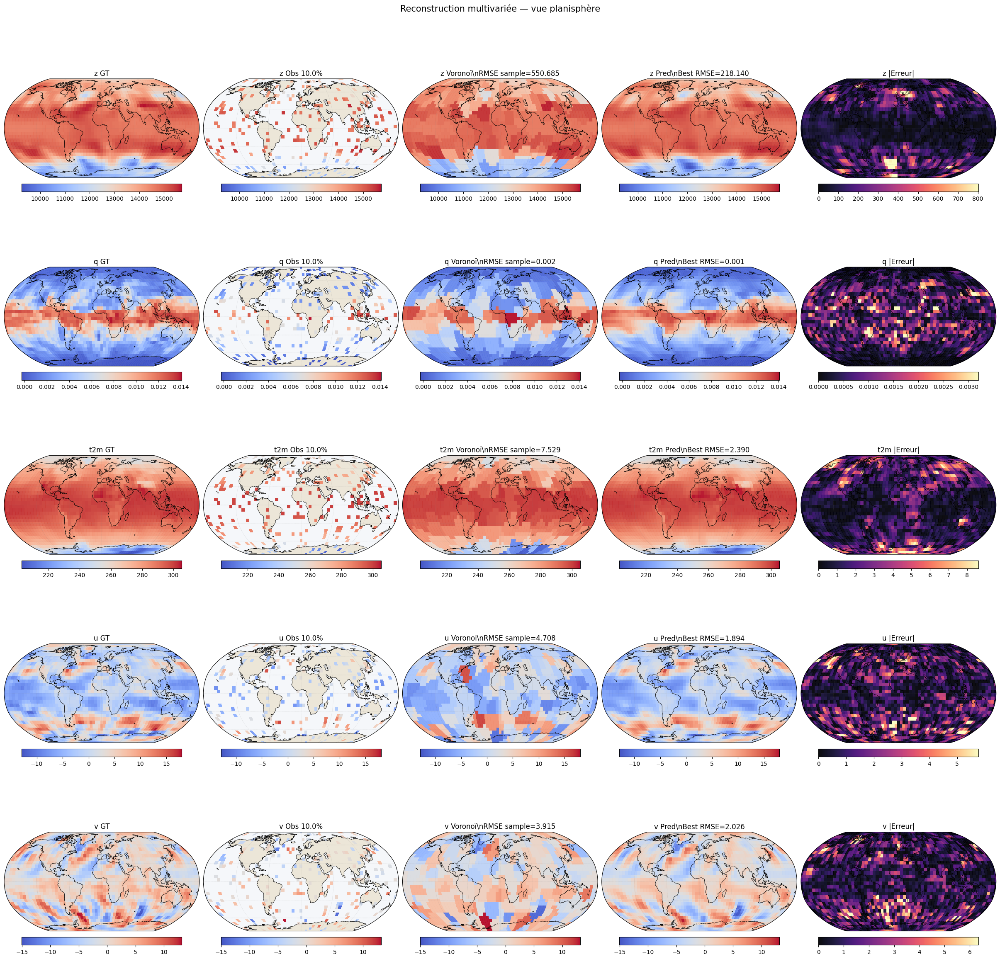

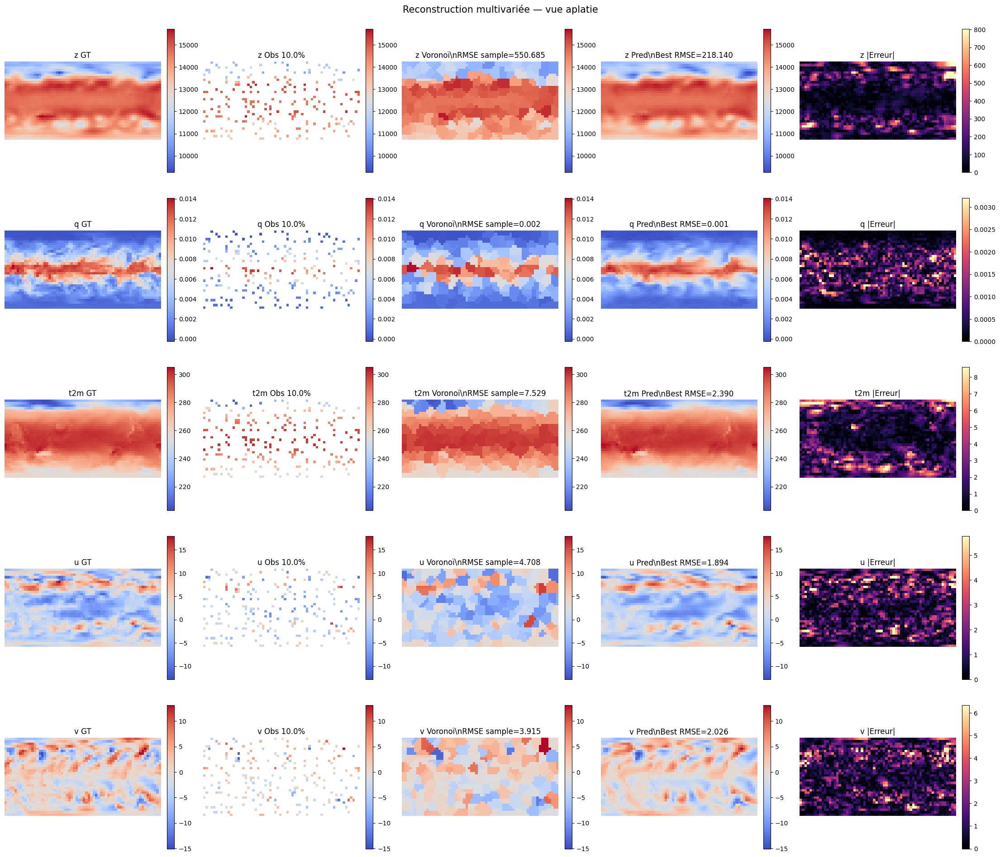

[F4] Visualisation sample test idx=1


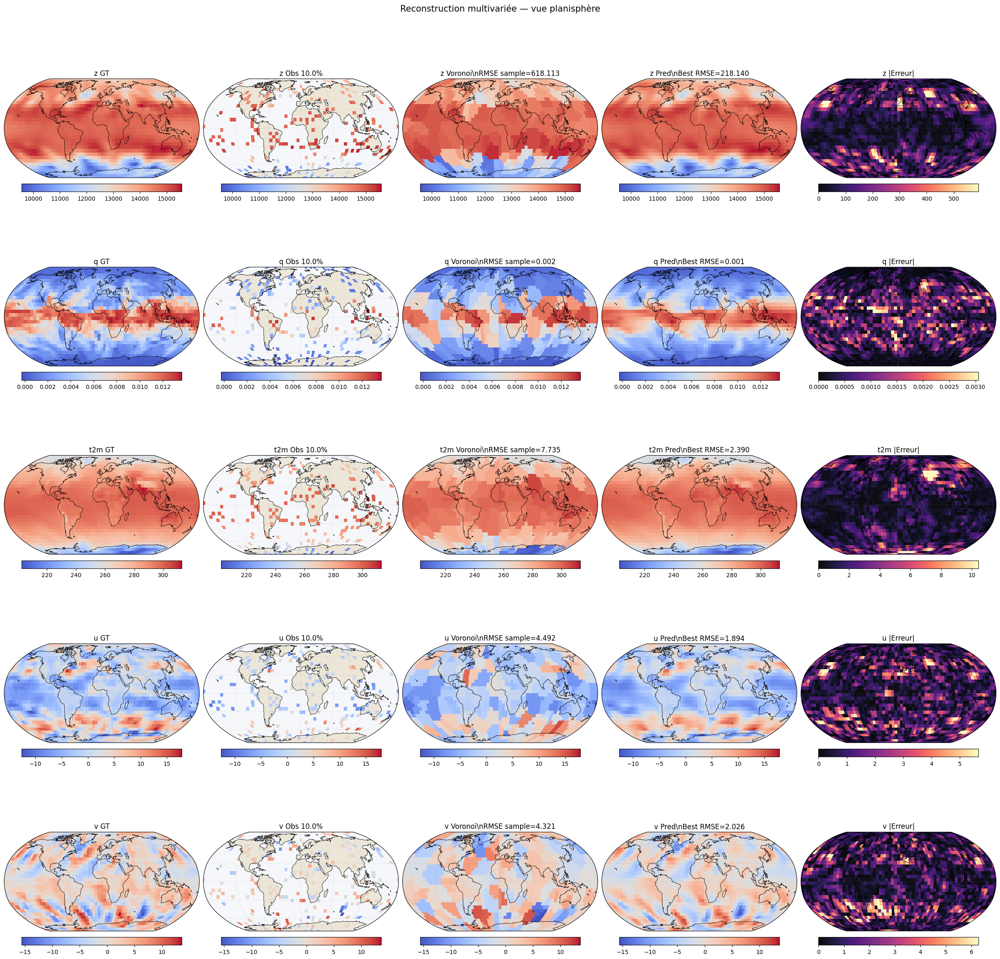

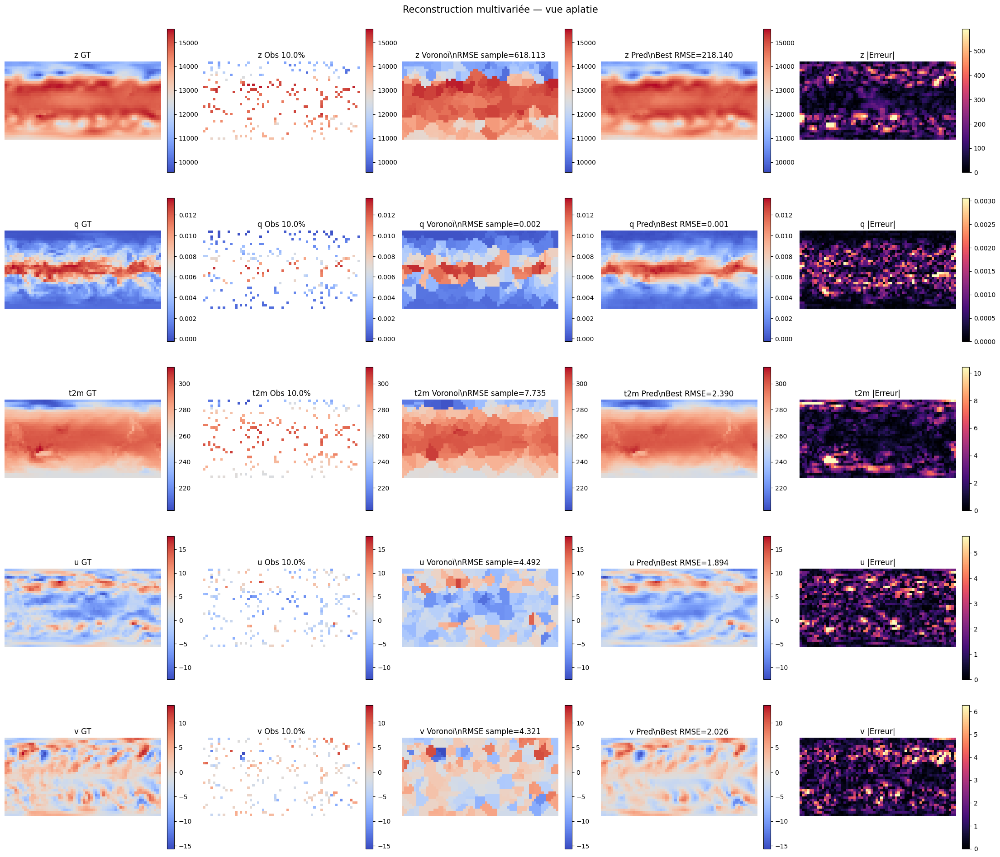

[F4] Visualisation sample test idx=2


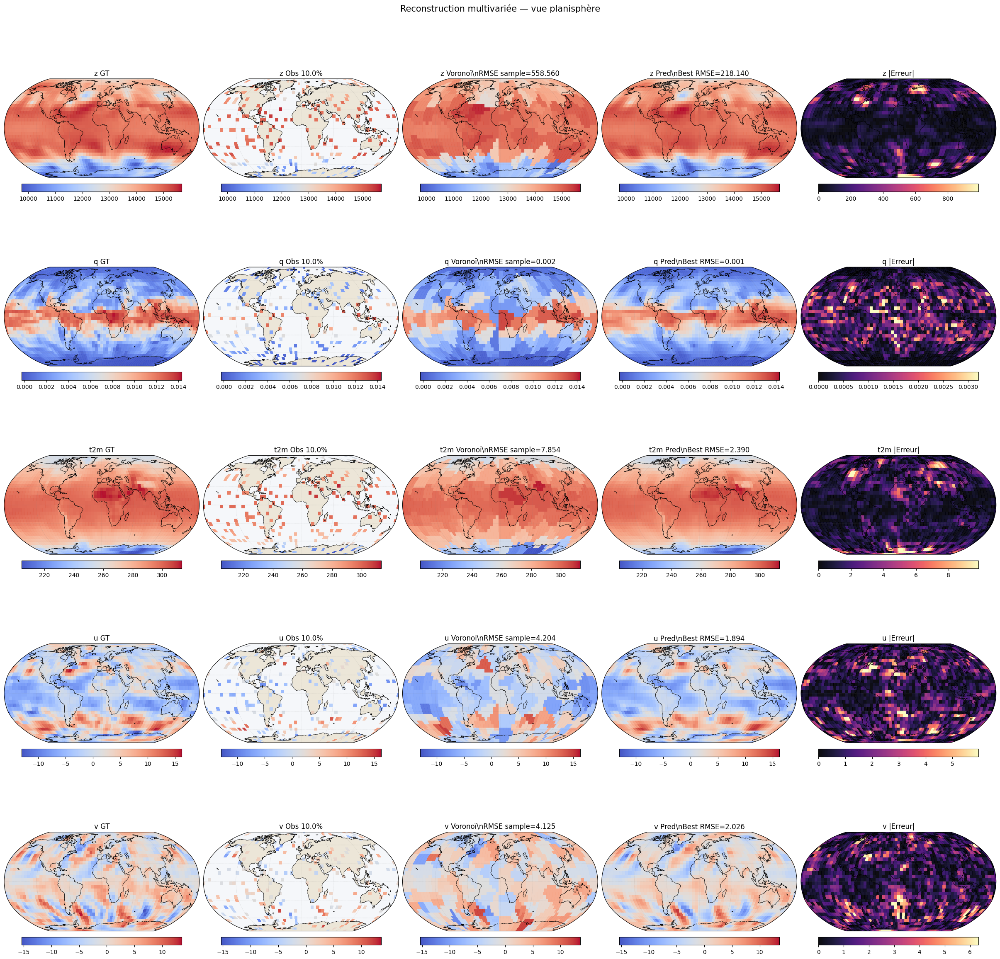

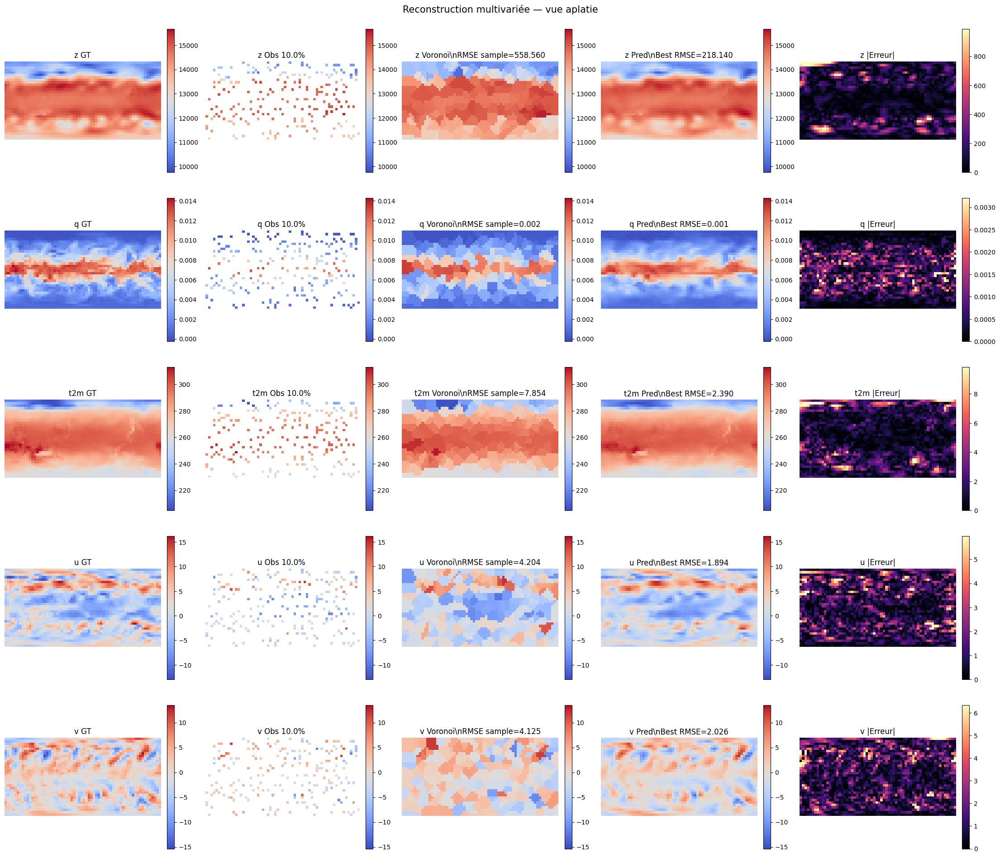

[F4] Visualisations affichées: 3
[F5] Vérification variation des masques...
  Train: diff moyen epoch1 vs epoch2 = 0.183594 (0 => identique)
  Val  : diff moyen accès A vs B = 0.000000 (attendu ~0)
  Test : diff moyen accès A vs B = 0.000000 (attendu ~0)


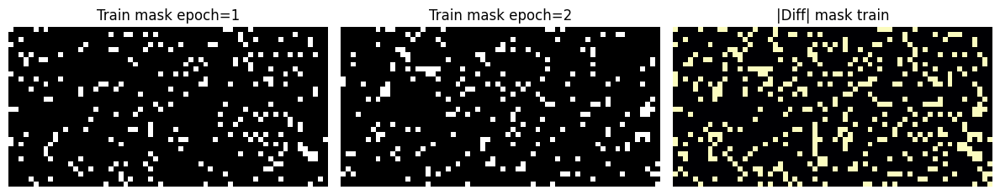

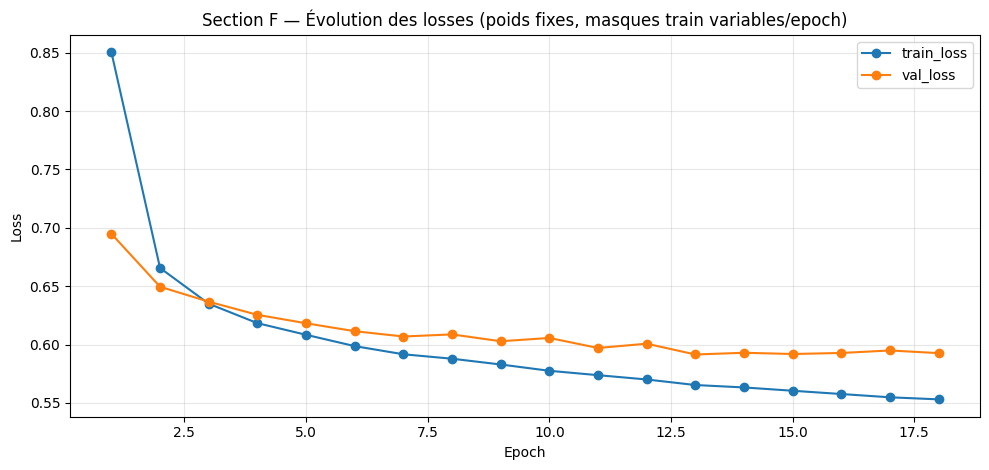

[F5] Courbe losses générée.
[F6] Protocole cross-densité: modèle F entraîné à 10% -> éval test 5%..49%
keep_ratio=5% | NRMSE=0.3577 | ACC=0.7853 | SSIM=0.7417
keep_ratio=6% | NRMSE=0.3347 | ACC=0.8143 | SSIM=0.7620
keep_ratio=7% | NRMSE=0.3196 | ACC=0.8310 | SSIM=0.7774
keep_ratio=8% | NRMSE=0.3029 | ACC=0.8483 | SSIM=0.7923
keep_ratio=9% | NRMSE=0.2914 | ACC=0.8596 | SSIM=0.8033
keep_ratio=10% | NRMSE=0.2804 | ACC=0.8695 | SSIM=0.8130
keep_ratio=11% | NRMSE=0.2707 | ACC=0.8780 | SSIM=0.8214
keep_ratio=12% | NRMSE=0.2624 | ACC=0.8854 | SSIM=0.8295
keep_ratio=13% | NRMSE=0.2557 | ACC=0.8909 | SSIM=0.8363
keep_ratio=14% | NRMSE=0.2488 | ACC=0.8964 | SSIM=0.8426
keep_ratio=15% | NRMSE=0.2429 | ACC=0.9010 | SSIM=0.8480
keep_ratio=16% | NRMSE=0.2377 | ACC=0.9048 | SSIM=0.8533
keep_ratio=17% | NRMSE=0.2327 | ACC=0.9086 | SSIM=0.8574
keep_ratio=18% | NRMSE=0.2279 | ACC=0.9123 | SSIM=0.8624
keep_ratio=19% | NRMSE=0.2240 | ACC=0.9151 | SSIM=0.8655
keep_ratio=20% | NRMSE=0.2201 | ACC=0.9177 | SS

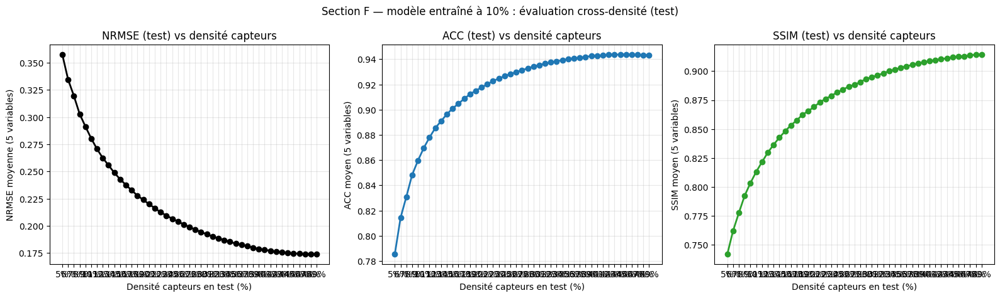

[F6] Courbes cross-densité générées.


In [15]:
# ── F4. Évaluation + comparaison C1 + qualitatif ───────────────────────────
print('── Résultats Section F (masque train variable/epoch) ──')
results_f = evaluate_multivariate(
    model_f, test_loader_f, keys_f, means_f, stds_f, device,
    climatology_maps=CLIM_MV_MAPS_F if "CLIM_MV_MAPS_F" in globals() else None,
    lat_weights_2d=LAT_WEIGHTS_2D_F if "LAT_WEIGHTS_2D_F" in globals() else None,
)
print_results_multivariate(results_f)


def f_mean_metric(results, metric_key: str, keys):
    return float(np.mean([results[k][metric_key] for k in keys]))

nrmse_f = f_mean_metric(results_f, 'nrmse_global', keys_f)
acc_f   = f_mean_metric(results_f, 'acc', keys_f)
ssim_f  = f_mean_metric(results_f, 'ssim', keys_f)

print('[F4] Moyennes F:')
print(f'  NRMSE global moyen : {nrmse_f:.4f}')
print(f'  ACC moyen          : {acc_f:.4f}')
print(f'  SSIM moyen         : {ssim_f:.4f}')

# Comparaison vs C1@10%
if 'results_by_ratio' in globals() and isinstance(results_by_ratio, dict) and len(results_by_ratio) > 0:
    ref_key_c1 = min(results_by_ratio.keys(), key=lambda r: abs(float(r) - 0.10))
    res_c1 = results_by_ratio[ref_key_c1]

    nrmse_c1 = f_mean_metric(res_c1, 'nrmse_global', keys_f)
    acc_c1   = f_mean_metric(res_c1, 'acc', keys_f)
    ssim_c1  = f_mean_metric(res_c1, 'ssim', keys_f)

    print('[F4] Comparaison vs C1 (StrongUNet fixe, keep_ratio≈10%):')
    print(f'  Ref key : {float(ref_key_c1):.2f}')
    print(f'  NRMSE : F={nrmse_f:.4f} | C1={nrmse_c1:.4f} | Δ={nrmse_f - nrmse_c1:+.4f}')
    print(f'  ACC   : F={acc_f:.4f}   | C1={acc_c1:.4f}   | Δ={acc_f - acc_c1:+.4f}')
    print(f'  SSIM  : F={ssim_f:.4f}  | C1={ssim_c1:.4f}  | Δ={ssim_f - ssim_c1:+.4f}')
else:
    print('[F4] results_by_ratio indisponible: comparaison C1 ignorée.')

# ── Qualitatif (même helper que B: globe + aplati) ───────────────────────
F_NUM_SAMPLES = 3
shown_f = min(F_NUM_SAMPLES, len(test_ds_f))
best_rmse_f = {k: results_f[k]['rmse_global'] for k in keys_f}

for sample_idx in range(shown_f):
    print(f'[F4] Visualisation sample test idx={sample_idx}')
    plot_multivariate_sample(
        model_f,
        test_ds_f,
        keys_f,
        means_f,
        stds_f,
        idx=sample_idx,
        device=device,
        best_rmse=best_rmse_f,
        ds_geo=ds_f,
    )

print(f'[F4] Visualisations affichées: {shown_f}')

# ── F5. Vérifications masques (train variable, eval stable) + courbe losses ──
print('[F5] Vérification variation des masques...')

if len(train_ds_f) > 0:
    i0 = 0
    train_ds_f.set_epoch(1)
    m_train_e1 = train_ds_f[i0][2][0].detach().cpu().numpy()
    train_ds_f.set_epoch(2)
    m_train_e2 = train_ds_f[i0][2][0].detach().cpu().numpy()
    train_diff_ratio = float(np.mean(np.abs(m_train_e1 - m_train_e2)))
    print(f'  Train: diff moyen epoch1 vs epoch2 = {train_diff_ratio:.6f} (0 => identique)')
else:
    m_train_e1 = m_train_e2 = None
    print('  Train: dataset vide, check ignoré.')

if len(val_ds_f) > 0:
    j0 = 0
    m_val_a = val_ds_f[j0][2][0].detach().cpu().numpy()
    m_val_b = val_ds_f[j0][2][0].detach().cpu().numpy()
    val_diff_ratio = float(np.mean(np.abs(m_val_a - m_val_b)))
    print(f'  Val  : diff moyen accès A vs B = {val_diff_ratio:.6f} (attendu ~0)')
else:
    m_val_a = m_val_b = None
    print('  Val: dataset vide, check ignoré.')

if len(test_ds_f) > 0:
    k0 = 0
    m_test_a = test_ds_f[k0][2][0].detach().cpu().numpy()
    m_test_b = test_ds_f[k0][2][0].detach().cpu().numpy()
    test_diff_ratio = float(np.mean(np.abs(m_test_a - m_test_b)))
    print(f'  Test : diff moyen accès A vs B = {test_diff_ratio:.6f} (attendu ~0)')
else:
    m_test_a = m_test_b = None
    print('  Test: dataset vide, check ignoré.')

# Visu masques train (epoch 1/2) + diff
if m_train_e1 is not None and m_train_e2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    axes[0].imshow(m_train_e1, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Train mask epoch=1')
    axes[0].axis('off')

    axes[1].imshow(m_train_e2, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Train mask epoch=2')
    axes[1].axis('off')

    axes[2].imshow(np.abs(m_train_e2 - m_train_e1), cmap='magma')
    axes[2].set_title('|Diff| mask train')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Courbe losses F
if 'hist_f' not in globals() or len(hist_f.get('epoch', [])) == 0:
    print('[F5] Aucun historique epoch parsé depuis train_model_fixed_weights_f.')
else:
    x = hist_f['epoch']
    plt.figure(figsize=(10, 4.8))
    plt.plot(x, hist_f['train_loss'], marker='o', label='train_loss')
    plt.plot(x, hist_f['val_loss'], marker='o', label='val_loss')
    plt.title('Section F — Évolution des losses (poids fixes, masques train variables/epoch)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print('[F5] Courbe losses générée.')


# ── F6. Protocole cross-densité (copie de C5 appliquée à F) ───────────────
import numpy as np
from torch.utils.data import DataLoader

F_EVAL_KEEP_RATIOS = [r / 100 for r in range(5, 50)]
f_cross_metrics = {'nrmse': [], 'acc': [], 'ssim': []}

print('[F6] Protocole cross-densité: modèle F entraîné à 10% -> éval test 5%..49%')

for keep_ratio_eval in F_EVAL_KEEP_RATIOS:
    test_mv_eval_f = MultiSparseVoronoiDataset(
        fields_f, keys_f, means_f, stds_f, idx_test_f,
        keep_ratio=keep_ratio_eval, base_seed=SEED_TEST
    )
    test_loader_eval_f = DataLoader(
        test_mv_eval_f,
        batch_size=F_BATCH_SIZE_EVAL,
        shuffle=False,
        num_workers=0,
    )

    res_eval_f = evaluate_multivariate(
        model_f, test_loader_eval_f, keys_f, means_f, stds_f, device,
        climatology_maps=CLIM_MV_MAPS_F if "CLIM_MV_MAPS_F" in globals() else None,
        lat_weights_2d=LAT_WEIGHTS_2D_F if "LAT_WEIGHTS_2D_F" in globals() else None,
    )

    nrmse_mean_f = float(np.mean([res_eval_f[k]['nrmse_global'] for k in keys_f]))
    acc_mean_f   = float(np.mean([res_eval_f[k]['acc'] for k in keys_f]))
    ssim_mean_f  = float(np.mean([res_eval_f[k]['ssim'] for k in keys_f]))

    f_cross_metrics['nrmse'].append(nrmse_mean_f)
    f_cross_metrics['acc'].append(acc_mean_f)
    f_cross_metrics['ssim'].append(ssim_mean_f)

    print(f"keep_ratio={keep_ratio_eval:.0%} | NRMSE={nrmse_mean_f:.4f} | ACC={acc_mean_f:.4f} | SSIM={ssim_mean_f:.4f}")

x_f = [100 * r for r in F_EVAL_KEEP_RATIOS]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

axes[0].plot(x_f, f_cross_metrics['nrmse'], marker='o', linewidth=2, color='black')
axes[0].set_title('NRMSE (test) vs densité capteurs')
axes[0].set_xlabel('Densité capteurs en test (%)')
axes[0].set_ylabel('NRMSE moyenne (5 variables)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_f, f_cross_metrics['acc'], marker='o', linewidth=2, color='tab:blue')
axes[1].set_title('ACC (test) vs densité capteurs')
axes[1].set_xlabel('Densité capteurs en test (%)')
axes[1].set_ylabel('ACC moyen (5 variables)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_f, f_cross_metrics['ssim'], marker='o', linewidth=2, color='tab:green')
axes[2].set_title('SSIM (test) vs densité capteurs')
axes[2].set_xlabel('Densité capteurs en test (%)')
axes[2].set_ylabel('SSIM moyen (5 variables)')
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks(x_f)
    ax.set_xticklabels([f"{int(v)}%" for v in x_f])

plt.suptitle('Section F — modèle entraîné à 10% : évaluation cross-densité (test)')
plt.tight_layout()
plt.show()
print('[F6] Courbes cross-densité générées.')


## 12. Dense-to-dense forecasting

Train a +24 h model and a push-forward model with deterministic 80/20 teacher forcing.

### 12.1 Prepare one-step forecasting

In [16]:
# ── PF1. Setup forecast one-step dense -> dense (+24h) ───────────────────────
PF_FORECAST_HORIZON_STEPS = 4   # +24h avec pas ERA5 = 6h
PF_BATCH_SIZE_TRAIN = F_BATCH_SIZE_TRAIN if 'F_BATCH_SIZE_TRAIN' in globals() else 8
PF_BATCH_SIZE_EVAL = F_BATCH_SIZE_EVAL if 'F_BATCH_SIZE_EVAL' in globals() else 32
PF_UNET_BASE = F_UNET_BASE if 'F_UNET_BASE' in globals() else 64
PF_MAX_EPOCHS = F_MAX_EPOCHS if 'F_MAX_EPOCHS' in globals() else 30
PF_PATIENCE = F_PATIENCE if 'F_PATIENCE' in globals() else 5

required_pf = [
    'fields_f', 'keys_f', 'means_f', 'stds_f', 'idx_train_f', 'idx_val_f', 'idx_test_f',
    'CLIM_MV_MAPS_F', 'LAT_WEIGHTS_2D_F', 'StrongUNet', 'gradient_loss', 'train_model'
]
missing_pf = [name for name in required_pf if name not in globals()]
if missing_pf:
    raise RuntimeError(f'Exécute d\'abord la section F complète avant le push-forward. Manque: {missing_pf}')


class MultiForecastDatasetDense(Dataset):
    """
    x : (K,H,W) à t
    y : (K,H,W) à t+h
    m : (K,H,W) masque plein (dummy)
    """
    def __init__(self, fields, keys, means, stds, indices, horizon_steps=4):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.h = int(horizon_steps)
        split_idx = [int(t) for t in indices]
        split_set = set(split_idx)
        self.indices = np.array([t for t in split_idx if (t + self.h) in split_set], dtype=int)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t = int(self.indices[i])
        th = t + self.h
        x_ch, y_ch, m_ch = [], [], []
        for k in self.keys:
            mu, sig = self.means[k], self.stds[k]
            x_t = ((self.fields[k][t] - mu) / sig).astype(np.float32)
            y_h = ((self.fields[k][th] - mu) / sig).astype(np.float32)
            m_k = np.ones_like(x_t, dtype=np.float32)
            x_ch.append(x_t)
            y_ch.append(y_h)
            m_ch.append(m_k)
        return (
            torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32),
            torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32),
            torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32),
        )


pf_train_ds = MultiForecastDatasetDense(fields_f, keys_f, means_f, stds_f, idx_train_f, PF_FORECAST_HORIZON_STEPS)
pf_val_ds = MultiForecastDatasetDense(fields_f, keys_f, means_f, stds_f, idx_val_f, PF_FORECAST_HORIZON_STEPS)
pf_test_ds = MultiForecastDatasetDense(fields_f, keys_f, means_f, stds_f, idx_test_f, PF_FORECAST_HORIZON_STEPS)

pf_train_loader = DataLoader(pf_train_ds, batch_size=PF_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
pf_val_loader = DataLoader(pf_val_ds, batch_size=PF_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
pf_test_loader = DataLoader(pf_test_ds, batch_size=PF_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)


def loss_forecast_dense(pred, y, m):
    l_all = ((pred - y) ** 2).mean()
    return l_all + LAMBDA_GRAD * gradient_loss(pred, y)


device_pf = device
model_pf_onestep = StrongUNet(in_ch=len(keys_f), out_ch=len(keys_f), base=PF_UNET_BASE, dropout=0.3).to(device_pf)
opt_pf_onestep = torch.optim.Adam(model_pf_onestep.parameters(), lr=LR)

x_pf0, y_pf0, m_pf0 = pf_train_ds[0]
n_params_pf_onestep = sum(p.numel() for p in model_pf_onestep.parameters() if p.requires_grad)
print(f'[PF1] horizon_steps={PF_FORECAST_HORIZON_STEPS} | sample x={tuple(x_pf0.shape)} y={tuple(y_pf0.shape)} m={tuple(m_pf0.shape)}')
print(f'[PF1] dense ds sizes | train={len(pf_train_ds)} | val={len(pf_val_ds)} | test={len(pf_test_ds)}')
print(f'[PF1] One-step forecast model params: {n_params_pf_onestep:,} | base={PF_UNET_BASE} | device={device_pf}')

print('\
── Entraînement one-step dense -> dense (+24h) ───────────────────────────')
model_pf_onestep = train_model(
    model_pf_onestep,
    pf_train_loader,
    pf_val_loader,
    opt_pf_onestep,
    loss_fn_callable=loss_forecast_dense,
    device=device_pf,
    max_epochs=PF_MAX_EPOCHS,
    patience=PF_PATIENCE,
)


[PF1] horizon_steps=4 | sample x=(5, 32, 64) y=(5, 32, 64) m=(5, 32, 64)
[PF1] dense ds sizes | train=2796 | val=596 | test=596
[PF1] One-step forecast model params: 8,333,235 | base=64 | device=cuda
── Entraînement one-step dense -> dense (+24h) ───────────────────────────
Epoch 01 | train=0.72995 | val=0.61311
Epoch 02 | train=0.55729 | val=0.56997
Epoch 03 | train=0.50255 | val=0.54952
Epoch 04 | train=0.46105 | val=0.54575
Epoch 05 | train=0.42515 | val=0.54849
Epoch 06 | train=0.39090 | val=0.55024
Epoch 07 | train=0.36065 | val=0.56204
Epoch 08 | train=0.33394 | val=0.56166
Epoch 09 | train=0.31273 | val=0.57517
Early stopping à l'epoch 9.
Meilleur val loss : 0.54575


### 12.2 Configure push-forward rollout

In [ ]:
# ── PF2. Hyperparamètres push-forward + dataset rollout dense ────────────────
PUSHFWD_TRAIN_ROLLOUT_STEPS = 7   # entraînement push-forward
PUSHFWD_EVAL_DAYS = 7             # évaluation jusqu'à +10 jours
PUSHFWD_TF_ALPHA = 0.5            # x_next = alpha*GT + (1-alpha)*Pred
PUSHFWD_MAX_EPOCHS = PF_MAX_EPOCHS
PUSHFWD_PATIENCE = PF_PATIENCE
HOURS_PER_MODEL_STEP = PF_FORECAST_HORIZON_STEPS * 6
PUSHFWD_EVAL_ROLLOUT_STEPS = int((PUSHFWD_EVAL_DAYS * 24) / HOURS_PER_MODEL_STEP)
assert PUSHFWD_EVAL_ROLLOUT_STEPS * HOURS_PER_MODEL_STEP == PUSHFWD_EVAL_DAYS * 24


class MultiForecastRolloutDatasetDense(Dataset):
    """
    Retourne une séquence normalisée de longueur rollout_steps+1:
      seq[s] = X(t + s*h), s=0..rollout_steps, avec h=PF_FORECAST_HORIZON_STEPS
    shape: (S, K, H, W)
    """
    def __init__(self, fields, keys, means, stds, indices, horizon_steps=4, rollout_steps=3):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.h = int(horizon_steps)
        self.rollout_steps = int(rollout_steps)

        split_idx = [int(t) for t in indices]
        split_set = set(split_idx)
        self.indices = np.array(
            [
                t for t in split_idx
                if all((t + s * self.h) in split_set for s in range(self.rollout_steps + 1))
            ],
            dtype=int,
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t0 = int(self.indices[i])
        seq = []
        for s in range(self.rollout_steps + 1):
            ts = t0 + s * self.h
            ch = []
            for k in self.keys:
                mu, sig = self.means[k], self.stds[k]
                x = ((self.fields[k][ts] - mu) / sig).astype(np.float32)
                ch.append(x)
            seq.append(np.stack(ch, axis=0))
        return torch.tensor(np.stack(seq, axis=0), dtype=torch.float32)


pf_roll_train_ds = MultiForecastRolloutDatasetDense(
    fields_f, keys_f, means_f, stds_f, idx_train_f,
    horizon_steps=PF_FORECAST_HORIZON_STEPS,
    rollout_steps=PUSHFWD_TRAIN_ROLLOUT_STEPS,
)
pf_roll_val_ds = MultiForecastRolloutDatasetDense(
    fields_f, keys_f, means_f, stds_f, idx_val_f,
    horizon_steps=PF_FORECAST_HORIZON_STEPS,
    rollout_steps=PUSHFWD_TRAIN_ROLLOUT_STEPS,
)
pf_roll_test_ds = MultiForecastRolloutDatasetDense(
    fields_f, keys_f, means_f, stds_f, idx_test_f,
    horizon_steps=PF_FORECAST_HORIZON_STEPS,
    rollout_steps=PUSHFWD_EVAL_ROLLOUT_STEPS,
)

pf_roll_train_loader = DataLoader(pf_roll_train_ds, batch_size=PF_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
pf_roll_val_loader = DataLoader(pf_roll_val_ds, batch_size=PF_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
pf_roll_test_loader = DataLoader(pf_roll_test_ds, batch_size=PF_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)

seq0_train = pf_roll_train_ds[0]
seq0_eval = pf_roll_test_ds[0]
print(
    f'[PF2] Push-forward setup | train_rollout_steps={PUSHFWD_TRAIN_ROLLOUT_STEPS} | ' 
    f'eval_days={PUSHFWD_EVAL_DAYS} | eval_rollout_steps={PUSHFWD_EVAL_ROLLOUT_STEPS} | ' 
    f'alpha={PUSHFWD_TF_ALPHA:.2f}'
)
print(f'[PF2] seq_shape train={tuple(seq0_train.shape)} | eval={tuple(seq0_eval.shape)}')
print(f'[PF2] rollout ds sizes | train={len(pf_roll_train_ds)} | val={len(pf_roll_val_ds)} | test={len(pf_roll_test_ds)}')


[PF2] Push-forward setup | train_rollout_steps=7 | eval_days=7 | eval_rollout_steps=7 | alpha=0.30
[PF2] seq_shape train=(8, 5, 32, 64) | eval=(8, 5, 32, 64)
[PF2] rollout ds sizes | train=2772 | val=572 | test=572


### 12.3 Train and evaluate push-forward model

In [26]:
# ── PF3. Entraînement push-forward + évaluation rollout libre ────────────────
def _pushfwd_ratio_label(tf_alpha):
    gt_pct = int(round(100.0 * float(tf_alpha)))
    pred_pct = 100 - gt_pct
    return f"{gt_pct}/{pred_pct}"


PUSHFWD_RATIO_LABEL = _pushfwd_ratio_label(PUSHFWD_TF_ALPHA)


def train_pushforward_dense(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    rollout_steps,
    tf_alpha,
    max_epochs,
    patience,
):
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []

        for seq in train_loader:
            seq = seq.to(device)  # (B,S,K,H,W)
            x_curr = seq[:, 0]
            loss_total = 0.0

            for s in range(1, rollout_steps + 1):
                y_target = seq[:, s]

                optimizer.zero_grad()
                pred = model(x_curr)
                step_loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
                (step_loss / rollout_steps).backward()
                optimizer.step()

                loss_total += float(step_loss.item())

                if s < rollout_steps:
                    with torch.no_grad():
                        x_curr = tf_alpha * y_target + (1.0 - tf_alpha) * pred.detach()

            tr_losses.append(loss_total / rollout_steps)

        model.eval()
        val_step_losses = [[] for _ in range(rollout_steps)]
        with torch.no_grad():
            for seq in val_loader:
                seq = seq.to(device)
                x_curr = seq[:, 0]

                for s in range(1, rollout_steps + 1):
                    y_target = seq[:, s]
                    pred = model(x_curr)
                    step_loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
                    val_step_losses[s - 1].append(float(step_loss.item()))

                    if s < rollout_steps:
                        x_curr = pred

        tr_mean = float(np.mean(tr_losses))
        val_step_mean = [float(np.mean(v)) if len(v) > 0 else float("nan") for v in val_step_losses]
        va_mean = float(np.nanmean(val_step_mean))
        va_last = float(val_step_mean[-1])
        print(f"Epoch {epoch:02d} | train={tr_mean:.5f} | val_free_mean={va_mean:.5f} | val_free_last={va_last:.5f}")

        if va_mean < best_val - 1e-5:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping à l'epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f"Meilleur val loss (push-forward): {best_val:.5f}")
    return model


def evaluate_free_rollout_dense(model, loader, keys, means, stds, device, rollout_steps,
                                climatology_maps=None, lat_weights_2d=None):
    metrics = {
        s: {k: {"sse": 0.0, "n": 0.0, "acc_sum": 0.0, "acc_n": 0, "ssim_sum": 0.0, "ssim_n": 0} for k in keys}
        for s in range(1, rollout_steps + 1)
    }

    model.eval()
    with torch.no_grad():
        for seq in loader:
            seq = seq.to(device)
            x_curr = seq[:, 0]

            for s in range(1, rollout_steps + 1):
                y_target = seq[:, s]
                pred = model(x_curr)

                for i, k in enumerate(keys):
                    mu, sig = means[k], stds[k]
                    pred_k = pred[:, i] * sig + mu
                    y_k = y_target[:, i] * sig + mu

                    e2 = (pred_k - y_k) ** 2
                    metrics[s][k]["sse"] += float(e2.sum().item())
                    metrics[s][k]["n"] += float(e2.numel())

                    pred_np = pred_k.cpu().numpy()
                    y_np = y_k.cpu().numpy()
                    clim_k = climatology_maps[k]
                    for b in range(pred_np.shape[0]):
                        a = acc_2d(pred_np[b], y_np[b], clim_k, lat_weights_2d)
                        if np.isfinite(a):
                            metrics[s][k]["acc_sum"] += float(a)
                            metrics[s][k]["acc_n"] += 1
                        ss = ssim_2d(pred_np[b], y_np[b])
                        if np.isfinite(ss):
                            metrics[s][k]["ssim_sum"] += float(ss)
                            metrics[s][k]["ssim_n"] += 1

                x_curr = pred

    out = {}
    for s in range(1, rollout_steps + 1):
        out[s] = {}
        for k in keys:
            rmse_g = float(np.sqrt(metrics[s][k]["sse"] / max(metrics[s][k]["n"], 1.0)))
            out[s][k] = {
                "rmse_global": rmse_g,
                "nrmse_global": rmse_g / stds[k],
                "acc": float(metrics[s][k]["acc_sum"] / max(metrics[s][k]["acc_n"], 1)),
                "ssim": float(metrics[s][k]["ssim_sum"] / max(metrics[s][k]["ssim_n"], 1)),
            }
    return out


def evaluate_persistence_rollout_dense(loader, keys, means, stds, device, rollout_steps,
                                       climatology_maps=None, lat_weights_2d=None):
    metrics = {
        s: {k: {"sse": 0.0, "n": 0.0, "acc_sum": 0.0, "acc_n": 0, "ssim_sum": 0.0, "ssim_n": 0} for k in keys}
        for s in range(1, rollout_steps + 1)
    }

    with torch.no_grad():
        for seq in loader:
            seq = seq.to(device)
            x_ref = seq[:, 0]

            for s in range(1, rollout_steps + 1):
                y_target = seq[:, s]
                pred = x_ref

                for i, k in enumerate(keys):
                    mu, sig = means[k], stds[k]
                    pred_k = pred[:, i] * sig + mu
                    y_k = y_target[:, i] * sig + mu

                    e2 = (pred_k - y_k) ** 2
                    metrics[s][k]["sse"] += float(e2.sum().item())
                    metrics[s][k]["n"] += float(e2.numel())

                    pred_np = pred_k.cpu().numpy()
                    y_np = y_k.cpu().numpy()
                    clim_k = climatology_maps[k]
                    for b in range(pred_np.shape[0]):
                        a = acc_2d(pred_np[b], y_np[b], clim_k, lat_weights_2d)
                        if np.isfinite(a):
                            metrics[s][k]["acc_sum"] += float(a)
                            metrics[s][k]["acc_n"] += 1
                        ss = ssim_2d(pred_np[b], y_np[b])
                        if np.isfinite(ss):
                            metrics[s][k]["ssim_sum"] += float(ss)
                            metrics[s][k]["ssim_n"] += 1

    out = {}
    for s in range(1, rollout_steps + 1):
        out[s] = {}
        for k in keys:
            rmse_g = float(np.sqrt(metrics[s][k]["sse"] / max(metrics[s][k]["n"], 1.0)))
            out[s][k] = {
                "rmse_global": rmse_g,
                "nrmse_global": rmse_g / stds[k],
                "acc": float(metrics[s][k]["acc_sum"] / max(metrics[s][k]["acc_n"], 1)),
                "ssim": float(metrics[s][k]["ssim_sum"] / max(metrics[s][k]["ssim_n"], 1)),
            }
    return out


def print_rollout_summary(res_roll, keys, label, horizon_step_base=4):
    print(f"\n── {label} (rollout libre) ─────────────────────────────────────────")
    for s in sorted(res_roll.keys()):
        h_hours = int(s * horizon_step_base * 6)
        print(f"\nHorizon +{h_hours}h")
        print(f"  {'Var':>4s} | {'NRMSE':>8s} | {'ACC':>6s} | {'SSIM':>6s}")
        print("  " + "-" * 36)
        for k in keys:
            r = res_roll[s][k]
            print(f"  {k:>4s} | {r['nrmse_global']:8.4f} | {r['acc']:6.4f} | {r['ssim']:6.4f}")
        mean_nrmse = float(np.mean([res_roll[s][k]["nrmse_global"] for k in keys]))
        mean_acc = float(np.mean([res_roll[s][k]["acc"] for k in keys]))
        mean_ssim = float(np.mean([res_roll[s][k]["ssim"] for k in keys]))
        print("  " + "-" * 36)
        print(f"  {'moy.':>4s} | {mean_nrmse:8.4f} | {mean_acc:6.4f} | {mean_ssim:6.4f}")


model_pf_pushfwd = StrongUNet(in_ch=len(keys_f), out_ch=len(keys_f), base=PF_UNET_BASE, dropout=0.3).to(device_pf)
opt_pf_pushfwd = torch.optim.Adam(model_pf_pushfwd.parameters(), lr=LR)

print(f"\n── Entraînement push-forward {PUSHFWD_RATIO_LABEL} (Dense -> Dense) ─────────────────────")
model_pf_pushfwd = train_pushforward_dense(
    model=model_pf_pushfwd,
    train_loader=pf_roll_train_loader,
    val_loader=pf_roll_val_loader,
    optimizer=opt_pf_pushfwd,
    device=device_pf,
    rollout_steps=PUSHFWD_TRAIN_ROLLOUT_STEPS,
    tf_alpha=PUSHFWD_TF_ALPHA,
    max_epochs=PUSHFWD_MAX_EPOCHS,
    patience=PUSHFWD_PATIENCE,
)

res_roll_onestep = evaluate_free_rollout_dense(
    model=model_pf_onestep,
    loader=pf_roll_test_loader,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device_pf,
    rollout_steps=PUSHFWD_EVAL_ROLLOUT_STEPS,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)

res_roll_pushfwd = evaluate_free_rollout_dense(
    model=model_pf_pushfwd,
    loader=pf_roll_test_loader,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device_pf,
    rollout_steps=PUSHFWD_EVAL_ROLLOUT_STEPS,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)

res_roll_persist = evaluate_persistence_rollout_dense(
    loader=pf_roll_test_loader,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device_pf,
    rollout_steps=PUSHFWD_EVAL_ROLLOUT_STEPS,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)

print_rollout_summary(res_roll_onestep, keys_f, label="One-step dense", horizon_step_base=PF_FORECAST_HORIZON_STEPS)
print_rollout_summary(
    res_roll_pushfwd,
    keys_f,
    label=f"Push-forward {PUSHFWD_RATIO_LABEL}",
    horizon_step_base=PF_FORECAST_HORIZON_STEPS,
)
print_rollout_summary(res_roll_persist, keys_f, label="Persistance dense", horizon_step_base=PF_FORECAST_HORIZON_STEPS)

print("\nDelta NRMSE (push-forward - one-step), par horizon:")
for s in range(1, PUSHFWD_EVAL_ROLLOUT_STEPS + 1):
    h_hours = int(s * PF_FORECAST_HORIZON_STEPS * 6)
    mean_push = float(np.mean([res_roll_pushfwd[s][k]["nrmse_global"] for k in keys_f]))
    mean_one = float(np.mean([res_roll_onestep[s][k]["nrmse_global"] for k in keys_f]))
    print(f"Horizon +{h_hours}h | delta={mean_push - mean_one:+.4f}")


── Entraînement push-forward 30/70 (Dense -> Dense) ─────────────────────
Epoch 01 | train=0.84311 | val_free_mean=1.30370 | val_free_last=1.59439
Epoch 02 | train=0.59937 | val_free_mean=1.35224 | val_free_last=1.67852
Epoch 03 | train=0.44073 | val_free_mean=1.41162 | val_free_last=1.71616
Epoch 04 | train=0.35934 | val_free_mean=1.38477 | val_free_last=1.67876
Epoch 05 | train=0.31218 | val_free_mean=1.37704 | val_free_last=1.68474
Epoch 06 | train=0.28108 | val_free_mean=1.43103 | val_free_last=1.75301
Early stopping à l'epoch 6.
Meilleur val loss (push-forward): 1.30370

── One-step dense (rollout libre) ─────────────────────────────────────────

Horizon +24h
   Var |    NRMSE |    ACC |   SSIM
  ------------------------------------
     z |   0.2131 | 0.8894 | 0.9351
     q |   0.1871 | 0.9116 | 0.9023
   t2m |   0.0808 | 0.9663 | 0.9766
     u |   0.4115 | 0.8597 | 0.7607
     v |   0.5133 | 0.8466 | 0.6755
  ------------------------------------
  moy. |   0.2812 | 0.8947 | 0.8

### 12.4 Compare forecast errors

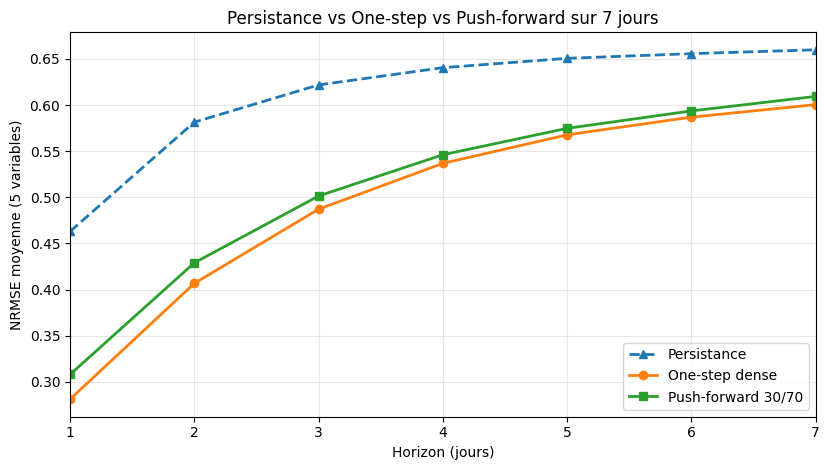

In [27]:
# ── PF4. Courbe NRMSE moyenne : persistance vs one-step vs push-forward ──────
if "PUSHFWD_RATIO_LABEL" not in globals():
    gt_pct = int(round(100.0 * float(PUSHFWD_TF_ALPHA)))
    PUSHFWD_RATIO_LABEL = f"{gt_pct}/{100 - gt_pct}"

def plot_pushforward_vs_baselines_over_eval_days(
    res_onestep,
    res_pushfwd,
    res_persist,
    keys,
    horizon_step_base,
    eval_days,
    pushfwd_ratio_label,
):
    horizons = sorted(res_onestep.keys())
    x_days = np.array([s * horizon_step_base * 6 / 24.0 for s in horizons], dtype=float)

    mean_one = np.array(
        [np.mean([res_onestep[s][k]["nrmse_global"] for k in keys]) for s in horizons],
        dtype=float,
    )
    mean_pf = np.array(
        [np.mean([res_pushfwd[s][k]["nrmse_global"] for k in keys]) for s in horizons],
        dtype=float,
    )
    mean_persist = np.array(
        [np.mean([res_persist[s][k]["nrmse_global"] for k in keys]) for s in horizons],
        dtype=float,
    )

    plt.figure(figsize=(8.4, 4.8))
    plt.plot(x_days, mean_persist, marker="^", linewidth=2, linestyle="--", label="Persistance")
    plt.plot(x_days, mean_one, marker="o", linewidth=2, label="One-step dense")
    plt.plot(x_days, mean_pf, marker="s", linewidth=2, label=f"Push-forward {pushfwd_ratio_label}")

    plt.xlim(1, eval_days)
    plt.xticks(np.arange(1, eval_days + 1, 1))
    plt.xlabel("Horizon (jours)")
    plt.ylabel("NRMSE moyenne (5 variables)")
    plt.title(f"Persistance vs One-step vs Push-forward sur {eval_days} jours")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pushforward_vs_baselines_over_eval_days(
    res_onestep=res_roll_onestep,
    res_pushfwd=res_roll_pushfwd,
    res_persist=res_roll_persist,
    keys=keys_f,
    horizon_step_base=PF_FORECAST_HORIZON_STEPS,
    eval_days=PUSHFWD_EVAL_DAYS,
    pushfwd_ratio_label=PUSHFWD_RATIO_LABEL,
)

## 13. Forecasting from reconstructed fields

Reconstruct the field at `t`, then compare push-forward predictions with six direct models for days 2–7. Generate maps and GIFs.

### 13.1 Prepare reconstructed-field forecasts

In [ ]:
# ── RPF1. Setup reconstruit -> push-forward + horizons directs ─────────────
import io
from pathlib import Path
from PIL import Image

RECON_DIRECT_HORIZON_DAYS = [2, 3, 4, 5, 6, 7]
RECON_GIF_SAMPLE_IDX = 0
RECON_GIF_FRAME_MS = 1100
RECON_GIF_OUTPUT_DIR = Path('artifacts/forecasting_gifs_recon_pf')
RECON_KEEP_RATIO = F_KEEP_RATIO if 'F_KEEP_RATIO' in globals() else 0.10
RECON_BATCH_SIZE_TRAIN = F_BATCH_SIZE_TRAIN if 'F_BATCH_SIZE_TRAIN' in globals() else 8
RECON_BATCH_SIZE_EVAL = F_BATCH_SIZE_EVAL if 'F_BATCH_SIZE_EVAL' in globals() else 32
RECON_UNET_BASE = PF_UNET_BASE if 'PF_UNET_BASE' in globals() else (F_UNET_BASE if 'F_UNET_BASE' in globals() else 64)
RECON_MAX_EPOCHS = PF_MAX_EPOCHS if 'PF_MAX_EPOCHS' in globals() else (F_MAX_EPOCHS if 'F_MAX_EPOCHS' in globals() else 30)
RECON_PATIENCE = PF_PATIENCE if 'PF_PATIENCE' in globals() else (F_PATIENCE if 'F_PATIENCE' in globals() else 5)
RECON_ONESTEP_HORIZON_STEPS = PF_FORECAST_HORIZON_STEPS if 'PF_FORECAST_HORIZON_STEPS' in globals() else 4
RECON_PUSHFWD_TRAIN_ROLLOUT_DAYS = max(RECON_DIRECT_HORIZON_DAYS)
RECON_PUSHFWD_EVAL_DAYS = max(RECON_DIRECT_HORIZON_DAYS)
RECON_PUSHFWD_TF_ALPHA = PUSHFWD_TF_ALPHA if 'PUSHFWD_TF_ALPHA' in globals() else 0.5
RECON_WEIGHT_DECAY = WEIGHT_DECAY if 'WEIGHT_DECAY' in globals() else 1e-4
RECON_STEP_HOURS = RECON_ONESTEP_HORIZON_STEPS * 6
RECON_PUSHFWD_TRAIN_ROLLOUT_STEPS = RECON_PUSHFWD_TRAIN_ROLLOUT_DAYS
RECON_PUSHFWD_EVAL_ROLLOUT_STEPS = RECON_PUSHFWD_EVAL_DAYS
assert RECON_STEP_HOURS == 24, 'Le bloc reconstruit -> push-forward suppose un pas de modèle de +24h.'

required_rpf = [
    'model_f', 'fields_f', 'keys_f', 'means_f', 'stds_f',
    'idx_train_f', 'idx_val_f', 'idx_test_f',
    'StrongUNet', 'gradient_loss', 'acc_2d', 'ssim_2d',
    '_resolve_clim_mv', '_resolve_lat_weights',
    'SEED_TRAIN', 'SEED_VAL', 'SEED_TEST'
]
missing_rpf = [name for name in required_rpf if name not in globals()]
if missing_rpf:
    raise RuntimeError(f"Exécute d'abord la section F complète avant le bloc reconstruit -> forecast. Manque: {missing_rpf}")

recon_model = model_f
recon_model.eval()
for p in recon_model.parameters():
    p.requires_grad = False


def _filter_indices_for_future(indices, horizon_steps):
    idx = [int(t) for t in indices]
    idx_set = set(idx)
    horizon_steps = int(horizon_steps)
    return np.array([t for t in idx if (t + horizon_steps) in idx_set], dtype=int)


def _filter_indices_for_rollout(indices, step_horizon_steps, rollout_days):
    idx = [int(t) for t in indices]
    idx_set = set(idx)
    step_horizon_steps = int(step_horizon_steps)
    rollout_days = int(rollout_days)
    return np.array(
        [
            t for t in idx
            if all((t + s * step_horizon_steps) in idx_set for s in range(rollout_days + 1))
        ],
        dtype=int,
    )


class MultiSparseForecastTargetDataset(Dataset):
    """
    x_sparse : (3K,H,W) observations sparse / voronoï / mask à t
    y_target : (K,H,W) champ dense à t + horizon_steps
    m_dummy  : (K,H,W) masque plein (pour compatibilité d'évaluation)
    """
    def __init__(self, fields, keys, means, stds, indices, horizon_steps,
                 keep_ratio=0.10, base_seed=0, different_masks=False):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.h = int(horizon_steps)
        self.keep_ratio = float(keep_ratio)
        self.base_seed = int(base_seed)
        self.different_masks = bool(different_masks)
        self.indices = _filter_indices_for_future(indices, self.h)
        _, self.H, self.W = self.fields[self.keys[0]].shape

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t = int(self.indices[i])
        th = t + self.h
        rng_main = np.random.default_rng(self.base_seed + t)
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch, y_ch, m_ch = [], [], []
        for vi, k in enumerate(self.keys):
            field_t = self.fields[k][t]
            field_h = self.fields[k][th]
            mu, sig = self.means[k], self.stds[k]

            if self.different_masks:
                rng_k = np.random.default_rng(self.base_seed + t * 1000 + vi)
                mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask

            vor = voronoi_fill_from_sparse(field_t, mask)
            sparse = field_t * mask
            x_ch += [
                ((vor - mu) / sig).astype(np.float32),
                mask.astype(np.float32),
                ((sparse - mu) / sig).astype(np.float32),
            ]
            y_ch.append(((field_h - mu) / sig).astype(np.float32))
            m_ch.append(np.ones_like(field_h, dtype=np.float32))

        return (
            torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32),
            torch.tensor(np.stack(y_ch, axis=0), dtype=torch.float32),
            torch.tensor(np.stack(m_ch, axis=0), dtype=torch.float32),
        )


class MultiSparseForecastRolloutDataset(Dataset):
    """
    Retourne:
      x_sparse0 : (3K,H,W) à t0
      seq_future: (S,K,H,W) avec les champs denses normalisés à t0 + s*24h, s=1..S
    """
    def __init__(self, fields, keys, means, stds, indices,
                 step_horizon_steps=4, rollout_days=7,
                 keep_ratio=0.10, base_seed=0, different_masks=False):
        self.fields = fields
        self.keys = list(keys)
        self.means = means
        self.stds = stds
        self.step_h = int(step_horizon_steps)
        self.rollout_days = int(rollout_days)
        self.keep_ratio = float(keep_ratio)
        self.base_seed = int(base_seed)
        self.different_masks = bool(different_masks)
        self.indices = _filter_indices_for_rollout(indices, self.step_h, self.rollout_days)
        _, self.H, self.W = self.fields[self.keys[0]].shape

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        t0 = int(self.indices[i])
        rng_main = np.random.default_rng(self.base_seed + t0)
        shared_mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_main)

        x_ch = []
        for vi, k in enumerate(self.keys):
            field_t0 = self.fields[k][t0]
            mu, sig = self.means[k], self.stds[k]
            if self.different_masks:
                rng_k = np.random.default_rng(self.base_seed + t0 * 1000 + vi)
                mask = make_sparse_mask(self.H, self.W, self.keep_ratio, rng_k)
            else:
                mask = shared_mask
            vor = voronoi_fill_from_sparse(field_t0, mask)
            sparse = field_t0 * mask
            x_ch += [
                ((vor - mu) / sig).astype(np.float32),
                mask.astype(np.float32),
                ((sparse - mu) / sig).astype(np.float32),
            ]

        seq_future = []
        for day in range(1, self.rollout_days + 1):
            ts = t0 + day * self.step_h
            ch = []
            for k in self.keys:
                mu, sig = self.means[k], self.stds[k]
                ch.append(((self.fields[k][ts] - mu) / sig).astype(np.float32))
            seq_future.append(np.stack(ch, axis=0))

        return (
            torch.tensor(np.stack(x_ch, axis=0), dtype=torch.float32),
            torch.tensor(np.stack(seq_future, axis=0), dtype=torch.float32),
        )


common_train_starts_recon_pf = _filter_indices_for_rollout(
    idx_train_f, RECON_ONESTEP_HORIZON_STEPS, RECON_PUSHFWD_TRAIN_ROLLOUT_DAYS,
)
common_val_starts_recon_pf = _filter_indices_for_rollout(
    idx_val_f, RECON_ONESTEP_HORIZON_STEPS, RECON_PUSHFWD_TRAIN_ROLLOUT_DAYS,
)
common_test_starts_recon_pf = _filter_indices_for_rollout(
    idx_test_f, RECON_ONESTEP_HORIZON_STEPS, RECON_PUSHFWD_EVAL_DAYS,
)

print('[RPF1] Config reconstruit -> forecast:')
print(f'  horizons_directs_jours={RECON_DIRECT_HORIZON_DAYS}')
print(f'  keep_ratio={RECON_KEEP_RATIO:.0%} | base={RECON_UNET_BASE} | weight_decay={RECON_WEIGHT_DECAY}')
print(f'  batch_train={RECON_BATCH_SIZE_TRAIN} | batch_eval={RECON_BATCH_SIZE_EVAL}')
print(f'  max_epochs={RECON_MAX_EPOCHS} | patience={RECON_PATIENCE}')
print(f'  pas_modèle={RECON_STEP_HOURS}h | alpha={RECON_PUSHFWD_TF_ALPHA:.2f}')
print(f'  starts rollout communs | train={len(common_train_starts_recon_pf)} | val={len(common_val_starts_recon_pf)} | test={len(common_test_starts_recon_pf)}')
print(f'  gif_output_dir={RECON_GIF_OUTPUT_DIR}')


### 13.2 Define training and evaluation helpers

In [ ]:
# ── RPF2. Helpers d'entraînement / évaluation / comparaison / GIFs ───────
def _metric_buffer(keys):
    return {
        k: {'sse': 0.0, 'n': 0.0, 'acc_sum': 0.0, 'acc_n': 0, 'ssim_sum': 0.0, 'ssim_n': 0}
        for k in keys
    }


def _finalize_metric_buffer(metrics, keys, stds):
    out = {}
    for k in keys:
        rmse_g = float(np.sqrt(metrics[k]['sse'] / max(metrics[k]['n'], 1.0)))
        out[k] = {
            'rmse_global': rmse_g,
            'nrmse_global': rmse_g / stds[k],
            'acc': float(metrics[k]['acc_sum'] / max(metrics[k]['acc_n'], 1)),
            'ssim': float(metrics[k]['ssim_sum'] / max(metrics[k]['ssim_n'], 1)),
        }
    return out


def train_recon_conditioned_forecast(model, recon_model, train_loader, val_loader, optimizer,
                                     keys, device, label,
                                     max_epochs=30, patience=5):
    recon_model.eval()
    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []
        for x_sparse, y_target, _ in train_loader:
            x_sparse = x_sparse.to(device)
            y_target = y_target.to(device)

            with torch.no_grad():
                x_recon = recon_model(x_sparse)

            optimizer.zero_grad()
            pred = model(x_recon)
            loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
            loss.backward()
            optimizer.step()
            tr_losses.append(float(loss.item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_sparse, y_target, _ in val_loader:
                x_sparse = x_sparse.to(device)
                y_target = y_target.to(device)
                x_recon = recon_model(x_sparse)
                pred = model(x_recon)
                loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
                val_losses.append(float(loss.item()))

        tr_mean = float(np.mean(tr_losses)) if len(tr_losses) > 0 else float('nan')
        va_mean = float(np.mean(val_losses)) if len(val_losses) > 0 else float('nan')
        print(f'[{label}] Epoch {epoch:02d} | train={tr_mean:.5f} | val={va_mean:.5f}')

        if va_mean < best_val - 1e-5:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"[{label}] Early stopping à l'epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f'[{label}] Meilleur val loss: {best_val:.5f}')
    return model


def train_pushforward_reconstructed(model, recon_model, train_loader, val_loader, optimizer,
                                    keys, device, rollout_steps, tf_alpha=0.8,
                                    max_epochs=30, patience=5, label='RPF-pushfwd'):
    recon_model.eval()
    best_val, best_state, wait = float('inf'), None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        tr_losses = []

        for x_sparse0, seq_future in train_loader:
            x_sparse0 = x_sparse0.to(device)
            seq_future = seq_future.to(device)

            with torch.no_grad():
                x_curr = recon_model(x_sparse0)

            loss_total = 0.0
            for day in range(rollout_steps):
                y_target = seq_future[:, day]

                optimizer.zero_grad()
                pred = model(x_curr)
                step_loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
                (step_loss / rollout_steps).backward()
                optimizer.step()
                loss_total += float(step_loss.item())

                if day + 1 < rollout_steps:
                    with torch.no_grad():
                        x_curr = tf_alpha * y_target + (1.0 - tf_alpha) * pred.detach()

            tr_losses.append(loss_total / rollout_steps)

        model.eval()
        val_step_losses = [[] for _ in range(rollout_steps)]
        with torch.no_grad():
            for x_sparse0, seq_future in val_loader:
                x_sparse0 = x_sparse0.to(device)
                seq_future = seq_future.to(device)
                x_curr = recon_model(x_sparse0)

                for day in range(rollout_steps):
                    y_target = seq_future[:, day]
                    pred = model(x_curr)
                    step_loss = ((pred - y_target) ** 2).mean() + LAMBDA_GRAD * gradient_loss(pred, y_target)
                    val_step_losses[day].append(float(step_loss.item()))
                    if day + 1 < rollout_steps:
                        x_curr = pred

        tr_mean = float(np.mean(tr_losses)) if len(tr_losses) > 0 else float('nan')
        val_step_mean = [float(np.mean(v)) if len(v) > 0 else float('nan') for v in val_step_losses]
        va_mean = float(np.nanmean(val_step_mean))
        va_last = float(val_step_mean[-1])
        print(f'[{label}] Epoch {epoch:02d} | train={tr_mean:.5f} | val_free_mean={va_mean:.5f} | val_free_last={va_last:.5f}')

        if va_mean < best_val - 1e-5:
            best_val = va_mean
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"[{label}] Early stopping à l'epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
        print(f'[{label}] Meilleur val loss (push-forward): {best_val:.5f}')
    return model


def evaluate_recon_direct_model(model, recon_model, loader, keys, means, stds, device,
                                climatology_maps=None, lat_weights_2d=None):
    clim_maps = _resolve_clim_mv(climatology_maps, keys)
    w_lat = _resolve_lat_weights(lat_weights_2d)
    metrics = _metric_buffer(keys)

    model.eval()
    recon_model.eval()
    with torch.no_grad():
        for x_sparse, y_target, _ in loader:
            x_sparse = x_sparse.to(device)
            y_target = y_target.to(device)
            x_recon = recon_model(x_sparse)
            pred = model(x_recon)

            for i, k in enumerate(keys):
                mu, sig = means[k], stds[k]
                pred_k = pred[:, i] * sig + mu
                y_k = y_target[:, i] * sig + mu

                e2 = (pred_k - y_k) ** 2
                metrics[k]['sse'] += float(e2.sum().item())
                metrics[k]['n'] += float(e2.numel())

                pred_np = pred_k.cpu().numpy()
                y_np = y_k.cpu().numpy()
                clim_k = clim_maps[k]
                for b in range(pred_np.shape[0]):
                    a = acc_2d(pred_np[b], y_np[b], clim_k, w_lat)
                    if np.isfinite(a):
                        metrics[k]['acc_sum'] += float(a)
                        metrics[k]['acc_n'] += 1
                    ss = ssim_2d(pred_np[b], y_np[b])
                    if np.isfinite(ss):
                        metrics[k]['ssim_sum'] += float(ss)
                        metrics[k]['ssim_n'] += 1

    return _finalize_metric_buffer(metrics, keys, stds)


def evaluate_free_rollout_reconstructed(model, recon_model, loader, keys, means, stds, device,
                                        rollout_steps, climatology_maps=None, lat_weights_2d=None):
    clim_maps = _resolve_clim_mv(climatology_maps, keys)
    w_lat = _resolve_lat_weights(lat_weights_2d)
    metrics = {s: _metric_buffer(keys) for s in range(1, rollout_steps + 1)}

    model.eval()
    recon_model.eval()
    with torch.no_grad():
        for x_sparse0, seq_future in loader:
            x_sparse0 = x_sparse0.to(device)
            seq_future = seq_future.to(device)
            x_curr = recon_model(x_sparse0)

            for s in range(1, rollout_steps + 1):
                y_target = seq_future[:, s - 1]
                pred = model(x_curr)

                for i, k in enumerate(keys):
                    mu, sig = means[k], stds[k]
                    pred_k = pred[:, i] * sig + mu
                    y_k = y_target[:, i] * sig + mu

                    e2 = (pred_k - y_k) ** 2
                    metrics[s][k]['sse'] += float(e2.sum().item())
                    metrics[s][k]['n'] += float(e2.numel())

                    pred_np = pred_k.cpu().numpy()
                    y_np = y_k.cpu().numpy()
                    clim_k = clim_maps[k]
                    for b in range(pred_np.shape[0]):
                        a = acc_2d(pred_np[b], y_np[b], clim_k, w_lat)
                        if np.isfinite(a):
                            metrics[s][k]['acc_sum'] += float(a)
                            metrics[s][k]['acc_n'] += 1
                        ss = ssim_2d(pred_np[b], y_np[b])
                        if np.isfinite(ss):
                            metrics[s][k]['ssim_sum'] += float(ss)
                            metrics[s][k]['ssim_n'] += 1

                x_curr = pred

    return {s: _finalize_metric_buffer(metrics[s], keys, stds) for s in range(1, rollout_steps + 1)}


def evaluate_persistence_reconstructed(loader, recon_model, keys, means, stds, device,
                                       rollout_steps, climatology_maps=None, lat_weights_2d=None):
    clim_maps = _resolve_clim_mv(climatology_maps, keys)
    w_lat = _resolve_lat_weights(lat_weights_2d)
    metrics = {s: _metric_buffer(keys) for s in range(1, rollout_steps + 1)}

    recon_model.eval()
    with torch.no_grad():
        for x_sparse0, seq_future in loader:
            x_sparse0 = x_sparse0.to(device)
            seq_future = seq_future.to(device)
            x_recon = recon_model(x_sparse0)

            for s in range(1, rollout_steps + 1):
                y_target = seq_future[:, s - 1]
                pred = x_recon

                for i, k in enumerate(keys):
                    mu, sig = means[k], stds[k]
                    pred_k = pred[:, i] * sig + mu
                    y_k = y_target[:, i] * sig + mu

                    e2 = (pred_k - y_k) ** 2
                    metrics[s][k]['sse'] += float(e2.sum().item())
                    metrics[s][k]['n'] += float(e2.numel())

                    pred_np = pred_k.cpu().numpy()
                    y_np = y_k.cpu().numpy()
                    clim_k = clim_maps[k]
                    for b in range(pred_np.shape[0]):
                        a = acc_2d(pred_np[b], y_np[b], clim_k, w_lat)
                        if np.isfinite(a):
                            metrics[s][k]['acc_sum'] += float(a)
                            metrics[s][k]['acc_n'] += 1
                        ss = ssim_2d(pred_np[b], y_np[b])
                        if np.isfinite(ss):
                            metrics[s][k]['ssim_sum'] += float(ss)
                            metrics[s][k]['ssim_n'] += 1

    return {s: _finalize_metric_buffer(metrics[s], keys, stds) for s in range(1, rollout_steps + 1)}


def _mean_metric(results, metric_key, keys):
    return float(np.mean([results[k][metric_key] for k in keys]))


def print_direct_vs_pushforward_reconstructed(res_direct_by_day, res_pushfwd, days, keys):
    print('\n── Comparaison Direct vs Push-forward (reconstruit à t) ─────────────────')
    for day in days:
        direct = res_direct_by_day[day]
        push = res_pushfwd[day]
        print(f'\nHorizon +{day}j')
        print(f"  {'Var':>4s} | {'Dir NRMSE':>9s} | {'PF NRMSE':>9s} | {'ΔNR':>7s} | {'Dir ACC':>7s} | {'PF ACC':>7s} | {'Dir SSIM':>8s} | {'PF SSIM':>8s}")
        print('  ' + '-' * 82)
        for k in keys:
            d = direct[k]
            p = push[k]
            print(
                f"  {k:>4s} | {d['nrmse_global']:9.4f} | {p['nrmse_global']:9.4f} | {d['nrmse_global'] - p['nrmse_global']:+7.4f} | "
                f"{d['acc']:7.4f} | {p['acc']:7.4f} | {d['ssim']:8.4f} | {p['ssim']:8.4f}"
            )
        print('  ' + '-' * 82)
        print(
            f"  {'moy.':>4s} | {_mean_metric(direct, 'nrmse_global', keys):9.4f} | {_mean_metric(push, 'nrmse_global', keys):9.4f} | "
            f"{_mean_metric(direct, 'nrmse_global', keys) - _mean_metric(push, 'nrmse_global', keys):+7.4f} | "
            f"{_mean_metric(direct, 'acc', keys):7.4f} | {_mean_metric(push, 'acc', keys):7.4f} | "
            f"{_mean_metric(direct, 'ssim', keys):8.4f} | {_mean_metric(push, 'ssim', keys):8.4f}"
        )


def plot_direct_vs_pushforward_reconstructed_curves(res_direct_by_day, res_pushfwd, days, keys):
    h_days = np.array(days, dtype=float)
    mean_direct = np.array([_mean_metric(res_direct_by_day[day], 'nrmse_global', keys) for day in days], dtype=float)
    mean_push = np.array([_mean_metric(res_pushfwd[day], 'nrmse_global', keys) for day in days], dtype=float)

    plt.figure(figsize=(7.8, 4.8))
    plt.plot(h_days, mean_direct, marker='o', linewidth=2, label='Direct reconstruit -> +nj')
    plt.plot(h_days, mean_push, marker='s', linewidth=2, label='Push-forward reconstruit 80/20')
    plt.xlabel('Horizon (jours)')
    plt.ylabel('NRMSE moyenne (5 variables)')
    plt.title('Direct vs Push-forward à partir du champ reconstruit à t')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_reconstructed_models_vs_persistence_curves(res_direct_by_day, res_pushfwd, res_persist, days, keys):
    h_days = np.array(days, dtype=float)
    mean_direct = np.array([_mean_metric(res_direct_by_day[day], 'nrmse_global', keys) for day in days], dtype=float)
    mean_push = np.array([_mean_metric(res_pushfwd[day], 'nrmse_global', keys) for day in days], dtype=float)
    mean_persist = np.array([_mean_metric(res_persist[day], 'nrmse_global', keys) for day in days], dtype=float)

    plt.figure(figsize=(8.2, 4.8))
    plt.plot(h_days, mean_direct, marker='o', linewidth=2, label='Direct / one-step reconstruit')
    plt.plot(h_days, mean_push, marker='s', linewidth=2, label='Push-forward reconstruit 80/20')
    plt.plot(h_days, mean_persist, marker='^', linewidth=2, linestyle='--', label='Persistance depuis t reconstruit')
    plt.xlabel('Horizon (jours)')
    plt.ylabel('NRMSE moyenne (5 variables)')
    plt.title('Reconstruit -> forecast : NRMSE moyenne vs persistance (J+1 a J+7)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_mean_delta_vs_persistence_by_day(res_by_label, res_persist, days, keys):
    print('\nDelta mean NRMSE vs persistance (modele - persistance):')
    for day in days:
        mean_persist = _mean_metric(res_persist[day], 'nrmse_global', keys)
        print(f'\nHorizon +{day}j | persistance={mean_persist:.4f}')
        for label, res_model in res_by_label.items():
            mean_model = _mean_metric(res_model[day], 'nrmse_global', keys)
            delta = mean_model - mean_persist
            verdict = 'OK' if delta < 0 else 'KO'
            print(f'  {label:<28} delta_mean={delta:+.4f} | model={mean_model:.4f} | {verdict}')


def _figure_to_rgb(fig, dpi=140):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    with Image.open(buf) as img:
        frame = np.asarray(img.convert('RGB'))
    buf.close()
    return frame


def _make_geo_forecast_frame(var_name, day, gt, pred_direct, pred_pushfwd, ds_geo=None, start_index=None):
    err_direct = np.abs(pred_direct - gt)
    err_push = np.abs(pred_pushfwd - gt)
    vmin = float(min(gt.min(), pred_direct.min(), pred_pushfwd.min()))
    vmax = float(max(gt.max(), pred_direct.max(), pred_pushfwd.max()))
    vmax_err = float(max(np.percentile(err_direct, 99), np.percentile(err_push, 99), 1e-6))

    fields = [gt, pred_direct, pred_pushfwd, err_direct, err_push]
    titles = [
        f'{var_name} GT +{day}j',
        f'{var_name} Direct +{day}j',
        f'{var_name} Push-forward +{day}j',
        f'{var_name} |Err Direct|',
        f'{var_name} |Err PF|',
    ]
    cmaps = ['coolwarm', 'coolwarm', 'coolwarm', 'magma', 'magma']
    vmins = [vmin, vmin, vmin, 0.0, 0.0]
    vmaxs = [vmax, vmax, vmax, vmax_err, vmax_err]

    fig = plt.figure(figsize=(24, 5.1), constrained_layout=True)
    if start_index is None:
        fig.suptitle(f'{var_name} — comparaison Direct vs Push-forward', fontsize=15)
    else:
        fig.suptitle(f'{var_name} — départ test t0={start_index} — horizon +{day}j', fontsize=15)

    for j in range(5):
        if _HAS_CARTOPY:
            ax = fig.add_subplot(1, 5, j + 1, projection=ccrs.Robinson())
        else:
            ax = fig.add_subplot(1, 5, j + 1)
        artist = _plot_geo_panel(
            ax,
            fields[j],
            titles[j],
            cmaps[j],
            vmin=vmins[j],
            vmax=vmaxs[j],
            ds_geo=ds_geo,
        )
        if artist is not None:
            fig.colorbar(artist, ax=ax, orientation='horizontal', pad=0.03, shrink=0.82)

    return _figure_to_rgb(fig)


def save_recon_direct_vs_pushforward_gifs(recon_model, pushforward_model, direct_models_by_day,
                                          rollout_test_ds, horizon_days, keys, means, stds,
                                          device, sample_index=0, output_dir=None,
                                          ds_geo=None, duration_ms=1100):
    if output_dir is None:
        output_dir = Path('artifacts/forecasting_gifs_recon_pf')
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if len(rollout_test_ds.indices) == 0:
        raise RuntimeError('Aucun départ de test commun disponible pour générer les GIFs reconstruit -> push-forward.')

    sample_pos = int(np.clip(sample_index, 0, len(rollout_test_ds.indices) - 1))
    t0 = int(rollout_test_ds.indices[sample_pos])
    x_sparse0, seq_future = rollout_test_ds[sample_pos]
    seq_future = seq_future.cpu()

    recon_model.eval()
    pushforward_model.eval()
    with torch.no_grad():
        x_sparse0_b = x_sparse0.unsqueeze(0).to(device)
        x_recon0 = recon_model(x_sparse0_b)

        direct_preds = {}
        for day in horizon_days:
            direct_models_by_day[day].eval()
            direct_preds[day] = direct_models_by_day[day](x_recon0).cpu().squeeze(0)

        push_preds = {}
        x_curr = x_recon0
        for day in range(1, max(horizon_days) + 1):
            pred = pushforward_model(x_curr)
            push_preds[day] = pred.cpu().squeeze(0)
            x_curr = pred

    gif_paths = {}
    for vi, k in enumerate(keys):
        mu, sig = means[k], stds[k]
        frames = []
        for day in horizon_days:
            gt = seq_future[day - 1, vi].numpy() * sig + mu
            pred_direct = direct_preds[day][vi].numpy() * sig + mu
            pred_push = push_preds[day][vi].numpy() * sig + mu
            frames.append(
                _make_geo_forecast_frame(
                    var_name=k,
                    day=day,
                    gt=gt,
                    pred_direct=pred_direct,
                    pred_pushfwd=pred_push,
                    ds_geo=ds_geo,
                    start_index=t0,
                )
            )

        pil_frames = [Image.fromarray(frame) for frame in frames]
        gif_path = output_dir / f'{k}_direct_vs_pushforward_days2-7.gif'
        pil_frames[0].save(
            gif_path,
            save_all=True,
            append_images=pil_frames[1:],
            duration=duration_ms,
            loop=0,
        )
        gif_paths[k] = gif_path

    return gif_paths


### 13.3 Train direct forecast models

In [ ]:
# ── RPF3. Jeux de donnees + modeles directs (one-step inclus) ─────────
# ── RPF3. Entraînement / comparaison officielle / GIFs ───────────────────
# Jeux de données
rpf_onestep_train_ds = MultiSparseForecastTargetDataset(
    fields_f, keys_f, means_f, stds_f, idx_train_f,
    horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_TRAIN,
)
rpf_onestep_val_ds = MultiSparseForecastTargetDataset(
    fields_f, keys_f, means_f, stds_f, idx_val_f,
    horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_VAL,
)
rpf_onestep_test_ds = MultiSparseForecastTargetDataset(
    fields_f, keys_f, means_f, stds_f, common_test_starts_recon_pf,
    horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_TEST,
)

rpf_roll_train_ds = MultiSparseForecastRolloutDataset(
    fields_f, keys_f, means_f, stds_f, idx_train_f,
    step_horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    rollout_days=RECON_PUSHFWD_TRAIN_ROLLOUT_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_TRAIN,
)
rpf_roll_val_ds = MultiSparseForecastRolloutDataset(
    fields_f, keys_f, means_f, stds_f, idx_val_f,
    step_horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    rollout_days=RECON_PUSHFWD_TRAIN_ROLLOUT_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_VAL,
)
rpf_roll_test_ds = MultiSparseForecastRolloutDataset(
    fields_f, keys_f, means_f, stds_f, common_test_starts_recon_pf,
    step_horizon_steps=RECON_ONESTEP_HORIZON_STEPS,
    rollout_days=RECON_PUSHFWD_EVAL_ROLLOUT_STEPS,
    keep_ratio=RECON_KEEP_RATIO,
    base_seed=SEED_TEST,
)

rpf_onestep_train_loader = DataLoader(rpf_onestep_train_ds, batch_size=RECON_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
rpf_onestep_val_loader = DataLoader(rpf_onestep_val_ds, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
rpf_onestep_test_loader = DataLoader(rpf_onestep_test_ds, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)

rpf_roll_train_loader = DataLoader(rpf_roll_train_ds, batch_size=RECON_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
rpf_roll_val_loader = DataLoader(rpf_roll_val_ds, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
rpf_roll_test_loader = DataLoader(rpf_roll_test_ds, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)

x_sparse_dbg, y_dbg, m_dbg = rpf_onestep_train_ds[0]
with torch.no_grad():
    x_recon_dbg = recon_model(x_sparse_dbg.unsqueeze(0).to(device)).cpu().squeeze(0)
seq_dbg = rpf_roll_test_ds[0][1]
print(f'[RPF3] sample sparse={tuple(x_sparse_dbg.shape)} | target={tuple(y_dbg.shape)} | dummy_m={tuple(m_dbg.shape)} | recon={tuple(x_recon_dbg.shape)}')
print(f'[RPF3] sample rollout seq={tuple(seq_dbg.shape)}')
print(f'[RPF3] datasets one-step | train={len(rpf_onestep_train_ds)} | val={len(rpf_onestep_val_ds)} | test_common={len(rpf_onestep_test_ds)}')
print(f'[RPF3] datasets rollout | train={len(rpf_roll_train_ds)} | val={len(rpf_roll_val_ds)} | test_common={len(rpf_roll_test_ds)}')

# Modèle one-step reconstruit -> +24h
model_recon_onestep = StrongUNet(in_ch=len(keys_f), out_ch=len(keys_f), base=RECON_UNET_BASE, dropout=0.3).to(device)
opt_recon_onestep = torch.optim.Adam(model_recon_onestep.parameters(), lr=LR, weight_decay=RECON_WEIGHT_DECAY)
params_recon_onestep = sum(p.numel() for p in model_recon_onestep.parameters() if p.requires_grad)
print(f'[RPF3] One-step recon forecast params: {params_recon_onestep:,}')
model_recon_onestep = train_recon_conditioned_forecast(
    model=model_recon_onestep,
    recon_model=recon_model,
    train_loader=rpf_onestep_train_loader,
    val_loader=rpf_onestep_val_loader,
    optimizer=opt_recon_onestep,
    keys=keys_f,
    device=device,
    label='RPF-one-step',
    max_epochs=RECON_MAX_EPOCHS,
    patience=RECON_PATIENCE,
)
res_recon_onestep = evaluate_recon_direct_model(
    model=model_recon_onestep,
    recon_model=recon_model,
    loader=rpf_onestep_test_loader,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)
print(
    f"[RPF-one-step test] NRMSE moyen={_mean_metric(res_recon_onestep, 'nrmse_global', keys_f):.4f} | "
    f"ACC moyen={_mean_metric(res_recon_onestep, 'acc', keys_f):.4f} | "
    f"SSIM moyen={_mean_metric(res_recon_onestep, 'ssim', keys_f):.4f}"
)

# Modèles directs indépendants +2j .. +7j
recon_direct_models = {1: model_recon_onestep}
recon_direct_results = {1: res_recon_onestep}
recon_direct_test_datasets_common = {1: rpf_onestep_test_ds}

for day in RECON_DIRECT_HORIZON_DAYS:
    horizon_steps = day * RECON_ONESTEP_HORIZON_STEPS
    train_ds_day = MultiSparseForecastTargetDataset(
        fields_f, keys_f, means_f, stds_f, idx_train_f,
        horizon_steps=horizon_steps,
        keep_ratio=RECON_KEEP_RATIO,
        base_seed=SEED_TRAIN,
    )
    val_ds_day = MultiSparseForecastTargetDataset(
        fields_f, keys_f, means_f, stds_f, idx_val_f,
        horizon_steps=horizon_steps,
        keep_ratio=RECON_KEEP_RATIO,
        base_seed=SEED_VAL,
    )
    test_ds_day_common = MultiSparseForecastTargetDataset(
        fields_f, keys_f, means_f, stds_f, common_test_starts_recon_pf,
        horizon_steps=horizon_steps,
        keep_ratio=RECON_KEEP_RATIO,
        base_seed=SEED_TEST,
    )

    train_loader_day = DataLoader(train_ds_day, batch_size=RECON_BATCH_SIZE_TRAIN, shuffle=True, num_workers=0)
    val_loader_day = DataLoader(val_ds_day, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)
    test_loader_day_common = DataLoader(test_ds_day_common, batch_size=RECON_BATCH_SIZE_EVAL, shuffle=False, num_workers=0)

    model_day = StrongUNet(in_ch=len(keys_f), out_ch=len(keys_f), base=RECON_UNET_BASE, dropout=0.3).to(device)
    opt_day = torch.optim.Adam(model_day.parameters(), lr=LR, weight_decay=RECON_WEIGHT_DECAY)
    params_day = sum(p.numel() for p in model_day.parameters() if p.requires_grad)
    print(f'\n── Entraînement direct reconstruit -> +{day}j | train={len(train_ds_day)} | val={len(val_ds_day)} | test_common={len(test_ds_day_common)} | params={params_day:,}')
    model_day = train_recon_conditioned_forecast(
        model=model_day,
        recon_model=recon_model,
        train_loader=train_loader_day,
        val_loader=val_loader_day,
        optimizer=opt_day,
        keys=keys_f,
        device=device,
        label=f'Direct+{day}j',
        max_epochs=RECON_MAX_EPOCHS,
        patience=RECON_PATIENCE,
    )

    res_day = evaluate_recon_direct_model(
        model=model_day,
        recon_model=recon_model,
        loader=test_loader_day_common,
        keys=keys_f,
        means=means_f,
        stds=stds_f,
        device=device,
        climatology_maps=CLIM_MV_MAPS_F,
        lat_weights_2d=LAT_WEIGHTS_2D_F,
    )

    recon_direct_models[day] = model_day
    recon_direct_results[day] = res_day
    recon_direct_test_datasets_common[day] = test_ds_day_common

    print(f'[Direct+{day}j] NRMSE moyen={_mean_metric(res_day, "nrmse_global", keys_f):.4f} | ACC moyen={_mean_metric(res_day, "acc", keys_f):.4f} | SSIM moyen={_mean_metric(res_day, "ssim", keys_f):.4f}')



### 13.4 Train push-forward model

In [ ]:
# ── RPF4. Push-forward reconstruit -> dense ───────────────────────────
# Push-forward reconstruit -> dense
model_recon_pushfwd = StrongUNet(in_ch=len(keys_f), out_ch=len(keys_f), base=RECON_UNET_BASE, dropout=0.3).to(device)
model_recon_pushfwd.load_state_dict(copy.deepcopy(model_recon_onestep.state_dict()))
opt_recon_pushfwd = torch.optim.Adam(model_recon_pushfwd.parameters(), lr=LR, weight_decay=RECON_WEIGHT_DECAY)
print('\n── Entraînement push-forward 80/20 (Sparse -> Reconstruit à t -> Forecast) ──')
model_recon_pushfwd = train_pushforward_reconstructed(
    model=model_recon_pushfwd,
    recon_model=recon_model,
    train_loader=rpf_roll_train_loader,
    val_loader=rpf_roll_val_loader,
    optimizer=opt_recon_pushfwd,
    keys=keys_f,
    device=device,
    rollout_steps=RECON_PUSHFWD_TRAIN_ROLLOUT_STEPS,
    tf_alpha=RECON_PUSHFWD_TF_ALPHA,
    max_epochs=RECON_MAX_EPOCHS,
    patience=RECON_PATIENCE,
    label='RPF-pushfwd',
)

res_roll_recon_pushfwd = evaluate_free_rollout_reconstructed(
    model=model_recon_pushfwd,
    recon_model=recon_model,
    loader=rpf_roll_test_loader,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device,
    rollout_steps=RECON_PUSHFWD_EVAL_ROLLOUT_STEPS,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)
res_roll_recon_persist = evaluate_persistence_reconstructed(
    loader=rpf_roll_test_loader,
    recon_model=recon_model,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device,
    rollout_steps=RECON_PUSHFWD_EVAL_ROLLOUT_STEPS,
    climatology_maps=CLIM_MV_MAPS_F,
    lat_weights_2d=LAT_WEIGHTS_2D_F,
)
print_rollout_summary(
    res_roll_recon_pushfwd,
    keys_f,
    label='Push-forward reconstruit 80/20',
    horizon_step_base=RECON_ONESTEP_HORIZON_STEPS,
)
print_rollout_summary(
    res_roll_recon_persist,
    keys_f,
    label='Persistance depuis champ reconstruit',
    horizon_step_base=RECON_ONESTEP_HORIZON_STEPS,
)



### 13.5 Compare forecasts and generate visualizations

In [ ]:
# ── RPF5. Comparaison officielle + visualisation + GIFs ───────────────
recon_curve_days = [1] + RECON_DIRECT_HORIZON_DAYS

print_direct_vs_pushforward_reconstructed(
    recon_direct_results,
    res_roll_recon_pushfwd,
    RECON_DIRECT_HORIZON_DAYS,
    keys_f,
)
plot_direct_vs_pushforward_reconstructed_curves(
    recon_direct_results,
    res_roll_recon_pushfwd,
    RECON_DIRECT_HORIZON_DAYS,
    keys_f,
)
plot_reconstructed_models_vs_persistence_curves(
    recon_direct_results,
    res_roll_recon_pushfwd,
    res_roll_recon_persist,
    recon_curve_days,
    keys_f,
)
print_mean_delta_vs_persistence_by_day(
    {
        'Direct / one-step reconstruit': recon_direct_results,
        'Push-forward reconstruit 80/20': res_roll_recon_pushfwd,
    },
    res_roll_recon_persist,
    recon_curve_days,
    keys_f,
)

recon_pushforward_gif_paths = save_recon_direct_vs_pushforward_gifs(
    recon_model=recon_model,
    pushforward_model=model_recon_pushfwd,
    direct_models_by_day=recon_direct_models,
    rollout_test_ds=rpf_roll_test_ds,
    horizon_days=RECON_DIRECT_HORIZON_DAYS,
    keys=keys_f,
    means=means_f,
    stds=stds_f,
    device=device,
    sample_index=RECON_GIF_SAMPLE_IDX,
    output_dir=RECON_GIF_OUTPUT_DIR,
    ds_geo=ds_f if 'ds_f' in globals() else None,
    duration_ms=RECON_GIF_FRAME_MS,
)

print('\n[RPF3] GIFs générés:')
for k, p in recon_pushforward_gif_paths.items():
    print(f'  {k}: {p}')
